<h1 style="background-color:#009999; color:white; padding:10px; border-radius:5px; text-align:center;">
Business Case Siemens Advanta
</h1>

Notebook made by: Group G <br>
Ana Rita Dias | 20250480 <br>
Catarina Santos | 20250501 <br>
Madalena Martins | 20211610 <br>
Maria Miguel Teixeira | 20250458 <br>
Marisa Ramos | 20250521 <br>

---------

<h2 style="color:#009999;">Import Libraries</h2>

In [126]:
!pip install -q lightgbm
!pip install xgboost
!pip install xgboost
!pip install numpy pandas scikit-learn tensorflow lightgbm xgboost statsmodels

In [127]:
# Warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
pd.reset_option('all')
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Modeling
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation of the model
from sklearn.metrics import mean_squared_error

# Stationarity test
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf

# Scaling
from sklearn.preprocessing import StandardScaler


In [128]:
train = pd.read_csv('data/train.csv') 
test = pd.read_csv('data/test.csv')

We remove the __Orders__ column from our training data to focus exclusively on __Revenue__.

In [129]:
train.drop(columns=['Orders cons. (anon)'], inplace=True)

Here we sort by subsegment and by period to ensure that the dataset flows correctly. 

In [130]:
TARGET = 'Revenue cons. (anon)'
SERIES_COL = 'TGL Business Subsegment'
TIME_COL = 'Period'

train = train.sort_values([SERIES_COL, TIME_COL]).reset_index(drop=True) #Sort the training dataset by the series column and time column to ensure that the data is in the correct order for time series analysis and modeling.
test = test.sort_values([SERIES_COL, TIME_COL]).reset_index(drop=True) #Sort the test dataset by the series column and time column to ensure that the data is in the correct order for time series analysis and modeling.

<h2 style="color:#009999;">Initial Analysis</h2>

In [131]:
train.shape

(4237, 42)

In [132]:
train[train.isna().any(axis=1)]

,Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Revenue cons. (anon),Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,Composite_Index_France,...,Global_Steel_Production_roll_std_3,Global_Interest_Rate_lag1,Global_Interest_Rate_lag3,Global_Interest_Rate_lag6,Global_Interest_Rate_lag12,Global_Interest_Rate_diff1,Global_Interest_Rate_diff3,Global_Interest_Rate_roll_mean_3,Global_Interest_Rate_roll_mean_6,Global_Interest_Rate_roll_std_3


In [133]:
test[test.isna().any(axis=1)]

,Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,Composite_Index_France,Composite_Index_Germany,...,Global_Steel_Production_roll_std_3,Global_Interest_Rate_lag1,Global_Interest_Rate_lag3,Global_Interest_Rate_lag6,Global_Interest_Rate_lag12,Global_Interest_Rate_diff1,Global_Interest_Rate_diff3,Global_Interest_Rate_roll_mean_3,Global_Interest_Rate_roll_mean_6,Global_Interest_Rate_roll_std_3


<h2 style="color:#009999;">Tendency of revenue and orders per time</h2>

Before training the model, we use the following code to visualize the global revenue trend and define a split point to separate our data into training and validation.

In [134]:
market_date = pd.read_excel("data/Case2_market_data_share.xlsx", sheet_name="Sheet2") #using the date for the graph description
train_date = train.merge(market_date, on="Period", how="left") 
train_date

,Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Revenue cons. (anon),Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,Composite_Index_France,...,Global_Interest_Rate_lag1,Global_Interest_Rate_lag3,Global_Interest_Rate_lag6,Global_Interest_Rate_lag12,Global_Interest_Rate_diff1,Global_Interest_Rate_diff3,Global_Interest_Rate_roll_mean_3,Global_Interest_Rate_roll_mean_6,Global_Interest_Rate_roll_std_3,DATE
0,1,SSI027,SSI02710,SSI02710,-390277,4.151566,2.066695,-0.689064,-0.017148,0.692497,...,-0.689064,-0.689064,-0.689064,-0.689064,0.000000,0.000000,-0.689064,-0.689064,0.000000,2021-04-01
1,2,SSI027,SSI02710,SSI02710,334,2.914200,2.236090,-0.689064,0.008453,0.217560,...,-0.689064,-0.689064,-0.689064,-0.689064,0.000000,0.000000,-0.689064,-0.689064,0.000000,2021-05-01
2,3,SSI027,SSI02710,SSI02710,334,1.178328,1.744846,-0.689064,0.230745,0.061597,...,-0.689064,-0.689064,-0.689064,-0.689064,0.000000,0.000000,-0.689064,-0.689064,0.000000,2021-06-01
3,4,SSI027,SSI02710,SSI02710,1811758,0.724330,1.143497,-0.689064,0.237258,-0.100381,...,-0.689064,-0.689064,-0.689064,-0.689064,0.000000,0.000000,-0.689064,-0.689064,0.000000,2021-07-01
4,5,SSI027,SSI02710,SSI02710,80112,0.110099,0.838588,-0.689064,0.202613,0.003346,...,-0.689064,-0.689064,-0.689064,-0.689064,0.000000,0.000000,-0.689064,-0.689064,0.000000,2021-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,42,SSI070,SSI07098,SSI07098,0,-0.815700,0.254178,2.088113,0.486062,0.774276,...,2.451790,2.451790,2.534445,2.534445,-0.363678,-0.363678,2.451790,2.493118,0.000000,2024-09-01
4233,15,SSI070,SSI07099,SSI07099,15584,-0.139155,1.439937,-0.193140,0.510981,0.766368,...,-0.441102,-0.606410,-0.689064,-0.689064,0.247962,0.413270,-0.551307,-0.620186,0.095441,2022-06-01
4234,18,SSI070,SSI07099,SSI07099,110210,0.492881,1.067270,0.716055,0.711541,0.971408,...,0.220131,-0.193140,-0.606410,-0.689064,0.495924,0.909195,0.082374,-0.234467,0.238602,2022-09-01
4235,21,SSI070,SSI07099,SSI07099,273671,-1.100561,0.279587,1.542596,0.722733,0.842049,...,1.211979,0.716055,-0.193140,-0.689064,0.330616,0.826541,0.964017,0.523196,0.247962,2022-12-01


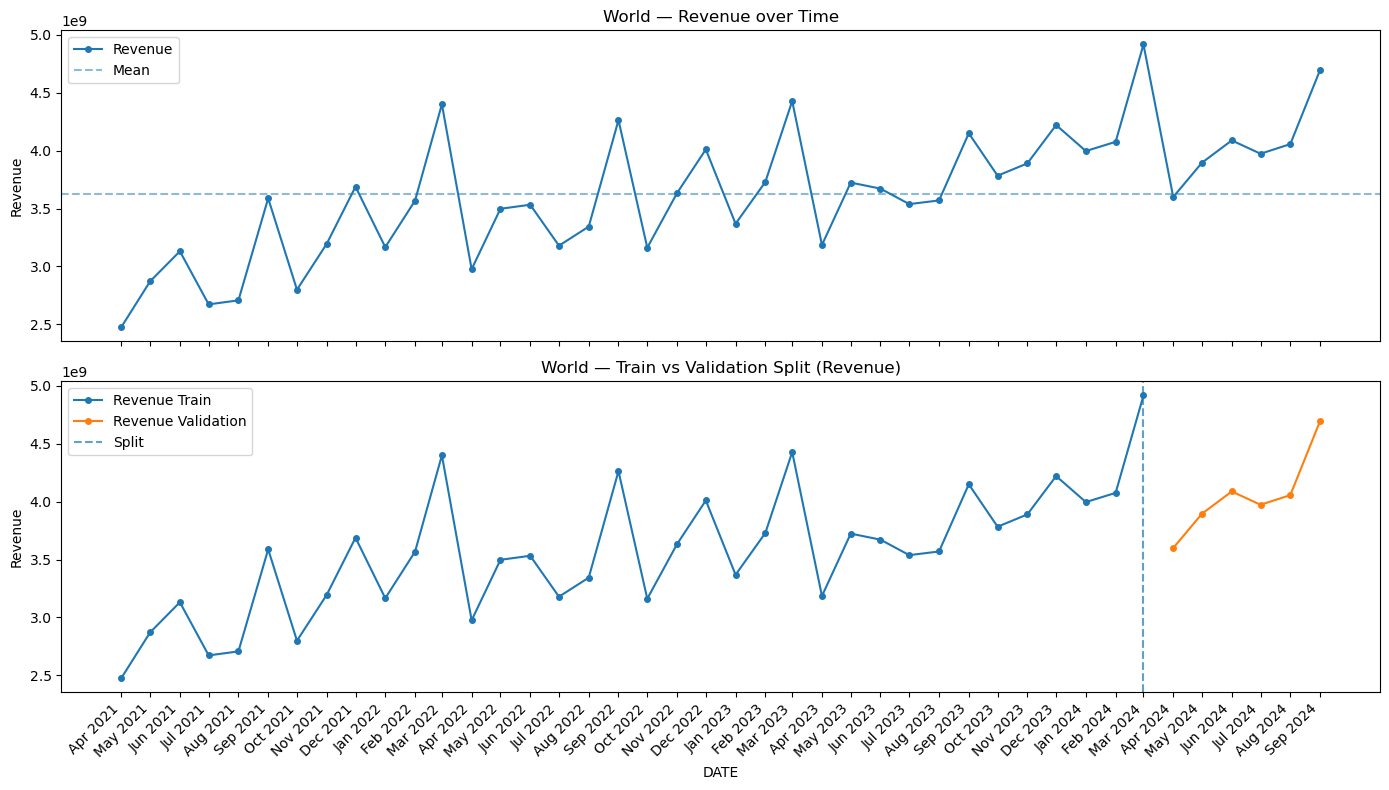

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

split_period = 36

# DATE is datetime
train_date['DATE'] = pd.to_datetime(train_date['DATE'])

#Aggregate revenue by period to visualize the overall trend in the data and compare the train and validation periods. 
#This will help to identify any patterns or seasonality in the revenue over time, and to assess the impact of the split on the revenue distribution.
world = (
    train_date.groupby('Period', as_index=False)
    .agg({
        'Revenue cons. (anon)': 'sum',
        'DATE': 'min'   # 👈 associar uma data a cada período
    })
    .sort_values('Period')
)

#Split the data into train and validation sets based on the defined split period to compare the revenue trends in the two periods and to evaluate 
# the performance of the model on unseen data.
train_part = world[world['Period'] <= split_period]
valid_part = world[world['Period'] > split_period]

#Revenue over Time ---
ax = axes[0]

ax.plot(world['DATE'], world['Revenue cons. (anon)'],
        marker='o', linewidth=1.5, markersize=4, label='Revenue')

ax.set_title('World — Revenue over Time')
ax.set_ylabel('Revenue')

#mean 
ax.axhline(world['Revenue cons. (anon)'].mean(),
           linestyle='--', alpha=0.5, label='Mean')

ax.legend(loc='upper left')


#Train vs Validation (Revenue)
ax = axes[1]

ax.plot(train_part['DATE'], train_part['Revenue cons. (anon)'],
        marker='o', linewidth=1.5, markersize=4, label='Revenue Train')

ax.plot(valid_part['DATE'], valid_part['Revenue cons. (anon)'],
        marker='o', linewidth=1.5, markersize=4, label='Revenue Validation')

#split (converter period -> date)
split_date = world.loc[world['Period'] == split_period, 'DATE'].iloc[0]

ax.axvline(split_date, linestyle='--', alpha=0.7, label='Split')

ax.set_title('World — Train vs Validation Split (Revenue)')
ax.set_xlabel('DATE')
ax.set_ylabel('Revenue')

ax.legend(loc='upper left')

#dates
tick_idx = range(0, len(world), 1)
tick_dates = world['DATE'].iloc[list(tick_idx)]

axes[1].set_xticks(tick_dates)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In the first graph (__World-Revenue over time__), the line represents the historic of revenue values over time. The fact that the model's "mean" line sits close to the center shows that the baseline is correct.
<br> <br>
In the second graph (__World-Train vs Validation Split__), we see the split line at period 36. The behaviour of the revenue after the split follow a similar pattern compared to the one before the split. This means our validation set is predictible and representative of the past.

<h2 style="color:#009999;">Feature creation (lags)</h2>

<h3 style="color:#009999;">Stationary test</h3>

In [136]:
#Try to identify a likely target column (numeric)
#We'll select the first numeric column after 'Period'
numeric_cols = train.select_dtypes(include='number').columns.tolist()

numeric_cols[:10]

['Period',
 'Revenue cons. (anon)',
 'Global_Industrial_Production',
 'Global_Steel_Production',
 'Global_Interest_Rate',
 'Composite_Index_China',
 'Composite_Index_France',
 'Composite_Index_Germany',
 'Composite_Index_Italy',
 'Composite_Index_United_Kindgom']

In [137]:
#Let's test stationarity on 'Revenue. (anon)'
series = train['Revenue cons. (anon)'].dropna()

adf_result = adfuller(series)

adf_result

(np.float64(-7.6872141923560955),
 np.float64(1.4508699712050412e-11),
 30,
 4206,
 {'1%': np.float64(-3.4319057050536026),
  '5%': np.float64(-2.862227424850339),
  '10%': np.float64(-2.5671359219817984)},
 np.float64(151707.91718885576))

In [138]:
for seg in train['TGL Business Unit'].unique():
    series = train[train['TGL Business Unit'] == seg]['Revenue cons. (anon)']
    #Select the revenue series for the current business unit segment to test its stationarity using the Augmented Dickey-Fuller test.
    result = adfuller(series.dropna())
    print(seg, result[1])  #p-value

SSI027 2.596238849339224e-05
SSI037 0.02680138712566332
SSI047 0.09097153705977146
SSI070 0.1219414125769806


In [139]:
world = train.groupby('Period')[['Revenue cons. (anon)']].sum().reset_index() #Aggregate revenue by period to visualize the overall trend in the data and compare the train and validation periods.
bu = train.groupby(['Period', 'TGL Business Unit'])[['Revenue cons. (anon)']].sum().reset_index() #Aggregate revenue by period and business unit to analyze the revenue trends for each business unit over time and to compare the performance of different business units in the dataset.
segment = train.groupby(['Period', 'TGL Business Segment'])[['Revenue cons. (anon)']].sum().reset_index() #Aggregate revenue by period and business segment to analyze the revenue trends for each business segment over time and to compare the performance of different business segments in the dataset.

In [140]:
train_times = train.copy()

In [141]:
def get_d(series, alpha=0.05):
    series = series.dropna() 
    #Drop any missing values from the series to ensure that the Augmented Dickey-Fuller test is performed on a complete dataset without any gaps, which could affect the accuracy of the test results.
    
    if len(series) < 20 or series.nunique() == 1: #If the series has less than 20 observations or is constant (only one unique value), it is not suitable for stationarity testing, and we return None to indicate that the differencing order cannot be determined for this series.
        return None
    
    p_value = adfuller(series)[1]
    return 0 if p_value < alpha else 1

In the following cell, we are implementing an automated seasonality detector. This is a way to confirm if the lags created are statistically meaningful for each specific subsegment.

In [142]:
#Detect seasonality in a time series by calculating the autocorrelation function (ACF) and checking for significant autocorrelation at lags corresponding to potential seasonal periods.
def detect_seasonality(series, max_lag=24, threshold=0.3): 
    series = series.dropna()
    
    if len(series) < max_lag:
        return False, None
    
    acf_vals = acf(series, nlags=max_lag)
    #Ignore lag 0 and lag 1 as they represent the correlation of the series with itself and the immediate past value, which are not indicative of seasonality. We start checking for seasonality from lag 2 onwards to identify any significant autocorrelation that may suggest a seasonal pattern in the data.
    for lag in range(2, max_lag): 
        if abs(acf_vals[lag]) > threshold: 
        #If the absolute value of the autocorrelation at a given lag exceeds the specified threshold, we consider that there is significant seasonality at that lag and return True along with the lag number.
            return True, lag
    
    return False, None

In [143]:
train_times.head()

,Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Revenue cons. (anon),Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,Composite_Index_France,...,Global_Steel_Production_roll_std_3,Global_Interest_Rate_lag1,Global_Interest_Rate_lag3,Global_Interest_Rate_lag6,Global_Interest_Rate_lag12,Global_Interest_Rate_diff1,Global_Interest_Rate_diff3,Global_Interest_Rate_roll_mean_3,Global_Interest_Rate_roll_mean_6,Global_Interest_Rate_roll_std_3
0,1,SSI027,SSI02710,SSI02710,-390277,4.151566,2.066695,-0.689064,-0.017148,0.692497,...,0.528684,-0.689064,-0.689064,-0.689064,-0.689064,0.0,0.0,-0.689064,-0.689064,0.0
1,2,SSI027,SSI02710,SSI02710,334,2.914200,2.236090,-0.689064,0.008453,0.217560,...,0.702850,-0.689064,-0.689064,-0.689064,-0.689064,0.0,0.0,-0.689064,-0.689064,0.0
2,3,SSI027,SSI02710,SSI02710,334,1.178328,1.744846,-0.689064,0.230745,0.061597,...,0.235787,-0.689064,-0.689064,-0.689064,-0.689064,0.0,0.0,-0.689064,-0.689064,0.0
3,4,SSI027,SSI02710,SSI02710,1811758,0.724330,1.143497,-0.689064,0.237258,-0.100381,...,0.249533,-0.689064,-0.689064,-0.689064,-0.689064,0.0,0.0,-0.689064,-0.689064,0.0
4,5,SSI027,SSI02710,SSI02710,80112,0.110099,0.838588,-0.689064,0.202613,0.003346,...,0.547220,-0.689064,-0.689064,-0.689064,-0.689064,0.0,0.0,-0.689064,-0.689064,0.0


Below, we have the exexcution of the stationary test. The code checks every individual subsegment, since they don't behave all the same way. <br>
- For subsegments with less than 5 cases, we identify as too small to test. <br>
- For the ones where Revenue never changes, it is define as stationary. <br>
- For the rest, we calculate the p-value and define non-stationary (has a trend) for the ones with a p-value greater than 0.05.

In [144]:
results = []

for subsegment, group in train_times.groupby("TGL Business Subsegment"):
    
    ts = group.sort_values("Period")["Revenue cons. (anon)"].dropna()
    
    #Short series
    if len(ts) < 5:
        results.append({
            "TGL Business Subsegment": subsegment,
            "n_obs": len(ts),
            "status": "too_short",
            "p_value": None,
            "is_stationary": None
        })
        continue
    
    #Constant series
    if ts.nunique() <= 1:
        results.append({
            "TGL Business Subsegment": subsegment,
            "n_obs": len(ts),
            "status": "constant_series",
            "p_value": None,
            "is_stationary": True   
    #If the series is constant, we can consider it as stationary since it does not exhibit any trends or seasonality, and its statistical properties do not change over time.
        })
        continue
    
    #ADF test
    try:
        adf_result = adfuller(ts)
        p_value = adf_result[1]
        
        results.append({
            "TGL Business Subsegment": subsegment,
            "n_obs": len(ts),
            "status": "tested",
            "p_value": p_value,
            "is_stationary": p_value < 0.05
        })
        
    except Exception as e:
        results.append({
            "TGL Business Subsegment": subsegment,
            "n_obs": len(ts),
            "status": f"error: {str(e)}",
            "p_value": None,
            "is_stationary": None
        })

results_df = pd.DataFrame(results)
results_df


,TGL Business Subsegment,n_obs,status,p_value,is_stationary
0,SSI02710,36,tested,4.466550e-07,True
1,SSI0271002,13,tested,5.848852e-01,False
2,SSI0271004,11,constant_series,NaN,True
3,SSI0271006,22,tested,NaN,False
4,SSI0271099,4,too_short,NaN,None
...,...,...,...,...,...
129,SSI0708230,18,tested,6.841452e-01,False
130,SSI0708299,1,too_short,NaN,None
131,SSI0708310,42,tested,6.522972e-01,False
132,SSI07098,3,too_short,NaN,None


Using the results from the previous step, we translate those findings into a simple binary variable (__is_stationary__). This acts as a "shortcut" for the model, providing instant context about each subsegment's behaviour.

In [145]:
#Create a new column 'stationary' in the results_df DataFrame and set its value to '1' for rows where either the 'is_stationary' column is True or the 'status' column indicates a constant series. This allows us to easily identify which time series are considered stationary based on the ADF test results or if they are constant.
results_df.loc[
    (results_df["is_stationary"] == True) | 
    (results_df["status"] == "constant_series"),
    "stationary"
] = '1'

In [146]:
#Updating the new column 'stationary' in the results_df DataFrame and set its value to '0' for rows where either the 'is_stationary' column is False or the 'status' column indicates that the series is too short. This allows us to easily identify which time series are considered non-stationary based on the ADF test results or if they are too short for testing.
results_df.loc[
    (results_df["is_stationary"] == False) | 
    (results_df["status"] == "too_short"),
    "stationary"
] = '0'

In [147]:
results_df.head()

,TGL Business Subsegment,n_obs,status,p_value,is_stationary,stationary
0,SSI02710,36,tested,4.466550e-07,True,1
1,SSI0271002,13,tested,5.848852e-01,False,0
2,SSI0271004,11,constant_series,NaN,True,1
3,SSI0271006,22,tested,NaN,False,0
4,SSI0271099,4,too_short,NaN,None,0


In [148]:
#Making sure that 'train_times' and 'results_df' have a common 'subsegment' column to merge the stationarity results back into the original training dataset. 
#This allows us to analyze the stationarity of each time series in the context of the original data and to use this information for further analysis or modeling.
train_times = train_times.merge(
    results_df[['TGL Business Subsegment', 'stationary']], 
    on='TGL Business Subsegment', 
    how='left'
)

In [149]:
#Making sure that 'test' and 'results_df' have a common 'subsegment' column to merge the stationarity results back into the original test dataset. 
#This allows us to analyze the stationarity of each time series in the context of the original data and to use this information further.
test_times = test.merge(
    results_df[['TGL Business Subsegment', 'stationary']], 
    on='TGL Business Subsegment', 
    how='left'
)

**Stationary**

In [150]:
df = pd.concat([train_times, test_times]) 
#Combine the training and test datasets into a single DataFrame to facilitate analysis and modeling across the entire dataset, allowing us to leverage all available data for insights and predictions.


While we above analyzed the data to see if it was stationary or seasonal, this function actually creates the numeric columns that allow the model to remember and react to changes over time.

In [151]:
def create_features(df):
    
    df = df.sort_values(["TGL Business Subsegment", "Period"])
    
 #Define a list of lag values to create lag features for the revenue series, which can help capture the temporal dependencies in the data and improve the performance of time series models.
    lags = [1, 2, 3, 4]
    for lag in lags:
        df[f"Revenue_lag_{lag}"] = (
            df.groupby("TGL Business Subsegment")["Revenue cons. (anon)"]
            .shift(lag)
        )
    
 #DIFFERENCES (important for non-stationary series)
    df["Revenue_diff_1"] = (
        df.groupby("TGL Business Subsegment")["Revenue cons. (anon)"]
        .diff(1)
    )
    
    df["Revenue_diff_3"] = (
        df.groupby("TGL Business Subsegment")["Revenue cons. (anon)"]
        .diff(3)
    )
    
#Rolling features to capture the local trends and variability in the revenue series, which can help improve the performance of time series models by providing additional 
#context about the recent behavior of the series.
    df["Revenue_roll_mean_3"] = (
        df.groupby("TGL Business Subsegment")["Revenue cons. (anon)"]
        .shift(1)
        .rolling(3)
        .mean()
    )
    
    df["Revenue_roll_std_3"] = (
        df.groupby("TGL Business Subsegment")["Revenue cons. (anon)"]
        .shift(1)
        .rolling(3)
        .std()
    )
    
    return df

In [152]:
df = create_features(df) #Apply the create_features function to the combined DataFrame to generate lag features, difference features, and rolling statistics 
#for the revenue series, which can enhance the predictive power of time series models by providing additional information about the temporal dynamics of the data.

In [153]:
lag_cols = [c for c in df.columns if "lag" in c] #Create a list of column names in the DataFrame that contain the substring "lag", which corresponds to the lag features created for the revenue series. This allows us to easily identify and work with the lag features in subsequent analysis or modeling steps.
roll_cols = ['Revenue_roll_std_3', 'Revenue_roll_mean_3', 'Revenue_diff_1', 'Revenue_diff_3']#Create a list of column names in the DataFrame that correspond to the rolling features and difference features created for the revenue series. This allows us to easily identify and work with these features in subsequent analysis or modeling steps.

The following code implements a smart imputation that treats missing data based on the specific nature of each subsegment. <br>
- For stationary, we use linear interpolation to bridge gaps smoothly within a consistent range. <br>
- For trending series, we apply a linear regression model to calculate the business's growth or decline trajectory, projecting that slope onto the missing periods.

In [154]:
#Fill missing values in a stationary time series using linear interpolation, forward fill, and backward fill methods to ensure that the series is complete and can be used for analysis or modeling without any gaps that could affect the results.
def fill_stationary(s): 
    return s.interpolate(method="linear", limit_direction="both").ffill().bfill()

#Fill missing values in a time series with a linear trend by fitting a linear regression to the non-missing values and using the fitted line to impute the missing values. This method helps to preserve the underlying trend in the data while filling in the gaps, which can be important for accurate analysis and modeling of time series data with trends.
def fill_trend(s):
    x = np.arange(len(s))
    mask = s.notna()
    
    if mask.sum() < 2: #If there are fewer than 2 non-missing values in the series, we cannot fit a linear trend, so we simply return the series with missing values filled using forward fill and backward fill methods to ensure that the series is complete for analysis or modeling.
        return s.ffill().bfill()
    
    coef = np.polyfit(x[mask], s[mask], 1) #Fit a linear regression to the non-missing values of the series by calculating the coefficients of the best-fitting line using the numpy polyfit function, which takes the indices of the non-missing values and their corresponding values as input.
    trend = np.polyval(coef, x)
    
    s[~mask] = trend[~mask] #Impute the missing values in the series with the corresponding values from the fitted linear trend, ensuring that the imputed values follow the underlying trend in the data.
    return s

In [155]:
df = df.sort_values(["TGL Business Subsegment", "Period"])

for col in lag_cols:
#If the series is stationary, we fill missing values using the fill_stationary function, which applies linear interpolation and forward/backward fill methods to ensure that the series is complete without introducing any trends or seasonality.
    df[col] = df.groupby("TGL Business Subsegment").apply(
        lambda g: (
            fill_stationary(g[col]) if g["stationary"].iloc[0] == 1 
            else fill_trend(g[col])
        )
    ).reset_index(level=0, drop=True)

In [156]:
def fill_roll_stationary(s):
    return s.interpolate().ffill().bfill()

def fill_roll_non_stationary(s):
    return s.ffill().bfill()
#Fill missing values in the rolling features and difference features based on the stationarity of the series. For stationary series, we use linear interpolation along with forward and backward fill methods to ensure that the imputed values are consistent with the properties of a stationary series. For non-stationary series, we use forward and backward fill methods to ensure that the imputed values do not introduce any artificial trends or seasonality into the data.
for col in roll_cols:
    df[col] = df.groupby("TGL Business Subsegment").apply(
        lambda g: (
            fill_roll_stationary(g[col]) if g["stationary"].iloc[0] == 1
            else fill_roll_non_stationary(g[col])
        )
    ).reset_index(level=0, drop=True)

In [157]:
df.head()

,Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Revenue cons. (anon),Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,Composite_Index_France,...,Global_Interest_Rate_roll_std_3,stationary,Revenue_lag_1,Revenue_lag_2,Revenue_lag_3,Revenue_lag_4,Revenue_diff_1,Revenue_diff_3,Revenue_roll_mean_3,Revenue_roll_std_3
0,1,SSI027,SSI02710,SSI02710,-390277.0,4.151566,2.066695,-0.689064,-0.017148,0.692497,...,0.0,1,1.428556e+05,148249.240841,153642.837237,163003.552941,390611.0,2202035.0,-129869.666667,2.255194e+05
1,2,SSI027,SSI02710,SSI02710,334.0,2.914200,2.236090,-0.689064,0.008453,0.217560,...,0.0,1,-3.902770e+05,142855.644444,148249.240841,157351.231373,390611.0,2202035.0,-129869.666667,2.255194e+05
2,3,SSI027,SSI02710,SSI02710,334.0,1.178328,1.744846,-0.689064,0.230745,0.061597,...,0.0,1,3.340000e+02,-390277.000000,142855.644444,151698.909804,0.0,2202035.0,-129869.666667,2.255194e+05
3,4,SSI027,SSI02710,SSI02710,1811758.0,0.724330,1.143497,-0.689064,0.237258,-0.100381,...,0.0,1,3.340000e+02,334.000000,-390277.000000,146046.588235,1811424.0,2202035.0,-129869.666667,2.255194e+05
4,5,SSI027,SSI02710,SSI02710,80112.0,0.110099,0.838588,-0.689064,0.202613,0.003346,...,0.0,1,1.811758e+06,334.000000,334.000000,-390277.000000,-1731646.0,79778.0,604142.000000,1.045826e+06


In [158]:
df_copy = df.copy()

In [159]:
base_features = df.columns.tolist()


In [160]:
df["stationary"] = pd.to_numeric(df["stationary"], errors='coerce') #Convert the 'stationary' column to numeric type, coercing any non-numeric values to NaN, to ensure that the stationarity information can be used effectively in analysis and modeling.

In [161]:
lag_cols = ["Revenue_lag_1", "Revenue_lag_3", "Revenue_lag_2", "Revenue_lag_4"] #Create a list of column names in the DataFrame that correspond to the lag features created for the revenue series. This allows us to easily identify and work with the lag features in subsequent analysis or modeling steps.
roll_cols = ["Revenue_roll_mean_3", "Revenue_roll_std_3"] #Create a list of column names in the DataFrame that correspond to the rolling features created for the revenue series. This allows us to easily identify and work with the rolling features in subsequent analysis or modeling steps.
diff_cols = ["Revenue_diff_1", "Revenue_diff_3"] #Create a list of column names in the DataFrame that correspond to the difference features created for the revenue series. This allows us to easily identify and work with the difference features in subsequent analysis or modeling steps.

for col in lag_cols:
    df[f"{col}_x_stat"] =df[col] * 0.75 #Create new features by multiplying the lag features by 0.75 for stationary series, which can help to capture the influence of past values on the current value while giving more weight to recent observations in the case of stationary series.
    
for col in roll_cols + diff_cols:
    df[f"{col}_x_nonstat"] = df[col] * (1 - 0.75) #Create new features by multiplying the rolling features and difference features by 0.25 for non-stationary series, which can help to capture the influence of past values on the current value while giving more weight to recent observations in the case of non-stationary series, where trends and seasonality may be present.
   

In [162]:
interaction_features = (
    [f"{col}_x_stat" for col in lag_cols] +
    [f"{col}_x_nonstat" for col in roll_cols + diff_cols]
)

feature_cols = base_features + interaction_features 
#Combine the base features and the newly created interaction features into a single list of feature column names that can be used for analysis and modeling, allowing us to leverage both the original features and the engineered features that capture interactions based on stationarity.

In [163]:
df=pd.DataFrame(df)

In [164]:
df.fillna(0, inplace=True)

In [165]:
df[['stationary','Revenue_diff_1','Revenue_lag_3','Revenue_lag_2','Revenue_lag_4','Revenue_roll_mean_3', 'Revenue_roll_std_3','Revenue_lag_1_x_stat','Revenue_lag_3_x_stat', 'Revenue_lag_2_x_stat', 'Revenue_lag_4_x_stat', 'Revenue_roll_mean_3_x_nonstat', 'Revenue_roll_std_3_x_nonstat', 'Revenue_diff_1_x_nonstat', 'Revenue_diff_3_x_nonstat']].tail(20)

,stationary,Revenue_diff_1,Revenue_lag_3,Revenue_lag_2,Revenue_lag_4,Revenue_roll_mean_3,Revenue_roll_std_3,Revenue_lag_1_x_stat,Revenue_lag_3_x_stat,Revenue_lag_2_x_stat,Revenue_lag_4_x_stat,Revenue_roll_mean_3_x_nonstat,Revenue_roll_std_3_x_nonstat,Revenue_diff_1_x_nonstat,Revenue_diff_3_x_nonstat
4223,0,624486.0,8.783517e+06,7.252445e+06,8.920177e+06,8.166324e+06,807503.748749,6.347258e+06,6.587638e+06,5.439334e+06,6.690133e+06,2.041581e+06,201875.937187,156121.50,75994.75
4224,0,-1307891.0,7.252445e+06,8.463010e+06,8.783517e+06,8.267650e+06,932993.618773,6.815622e+06,5.439334e+06,6.347258e+06,6.587638e+06,2.066913e+06,233248.404693,-326972.75,131790.00
4225,0,12463.0,8.463010e+06,9.087496e+06,7.252445e+06,8.443370e+06,654166.648760,5.834704e+06,6.347258e+06,6.815622e+06,5.439334e+06,2.110843e+06,163541.662190,3115.75,-167735.50
4226,0,201909.0,9.087496e+06,7.779605e+06,8.463010e+06,8.219723e+06,751539.297867,5.844051e+06,6.815622e+06,5.834704e+06,6.347258e+06,2.054931e+06,187884.824467,50477.25,-273379.75
4227,0,-929460.0,7.779605e+06,7.792068e+06,9.087496e+06,7.855217e+06,120331.434681,5.995483e+06,5.834704e+06,5.844051e+06,6.815622e+06,1.963804e+06,30082.858670,-232365.00,-178772.00
4228,0,243926.0,7.792068e+06,7.993977e+06,7.779605e+06,7.616854e+06,488875.170414,5.298388e+06,5.844051e+06,5.995483e+06,5.834704e+06,1.904214e+06,122218.792603,60981.50,-120906.25
4229,0,1192493.0,7.993977e+06,7.064517e+06,7.792068e+06,7.455646e+06,481897.750260,5.481332e+06,5.995483e+06,5.298388e+06,5.844051e+06,1.863911e+06,120474.437565,298123.25,126739.75
706,0,1192493.0,7.064517e+06,7.308443e+06,7.993977e+06,7.624632e+06,768639.381427,6.375702e+06,5.298388e+06,5.481332e+06,5.995483e+06,1.906158e+06,192159.845357,298123.25,126739.75
707,0,1192493.0,7.308443e+06,8.500936e+06,7.064517e+06,7.624632e+06,768639.381427,6.241192e+06,5.481332e+06,6.375702e+06,5.298388e+06,1.906158e+06,192159.845357,298123.25,126739.75
708,0,1192493.0,8.500936e+06,8.321589e+06,7.308443e+06,7.624632e+06,768639.381427,6.157256e+06,6.375702e+06,6.241192e+06,5.481332e+06,1.906158e+06,192159.845357,298123.25,126739.75


We drop these specific columns below immediately after using them because their primary purpose was to help us calculate the missing values (the "imputation" phase).

In [166]:
df.drop(["Revenue_lag_1", "Revenue_lag_3", "Revenue_lag_2", "Revenue_lag_4",
          "Revenue_roll_mean_3", "Revenue_roll_std_3", "Revenue_diff_1", "Revenue_diff_3"], axis=1, inplace=True)

In [167]:
df.shape

(4949, 51)

In [168]:
train = df[df["Period"].isin(train_times["Period"])] #Filter the combined DataFrame to include only the rows where the 'Period' column values are present in the 'Period' column of the train_times DataFrame, effectively creating a training dataset that contains only the periods that were originally in the training set for analysis and modeling.
test = df[df["Period"].isin(test_times["Period"])] #Filter the combined DataFrame to include only the rows where the 'Period' column values are present in the 'Period' column of the test_times DataFrame, effectively creating a test dataset that contains only the periods that were originally in the test set for analysis and modeling.

Now that we have created many new features (lags, rolling means, differences), we need to make sure we aren't overwhelming the model with redundant information. This next code calculates the __Correlation Matrix__ to find pairs of variables that are almost identical.

In [169]:
numerical_data = train.select_dtypes(include='number')
#Compute the absolute correlation matrix for all numerical variables
corr_matrix = numerical_data.corr().abs()

#Keep only the upper triangle of the matrix
#This avoids duplicated pairs (since correlation matrix is symmetric)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

#Convert the matrix into a list of variable pairs
high_corr = upper_tri.unstack()

#Identify pairs with correlation higher than 0.95
high_corr_list = high_corr[high_corr > 0.95].sort_values(ascending=False)

#Display the results
print("Pairs with correlation greater than 0.95:")

if high_corr_list.empty:
    print("No correlations above 0.95 were detected.")
else:
    print(high_corr_list.head(60))

Pairs with correlation greater than 0.95:
Global_Interest_Rate_roll_mean_6  Global_Interest_Rate_lag3           0.998678
Global_Interest_Rate_roll_mean_3  Global_Interest_Rate_lag3           0.997020
                                  Global_Interest_Rate_lag1           0.996985
Global_Interest_Rate_lag1         Global_Interest_Rate                0.994505
Global_Interest_Rate_roll_mean_6  Global_Interest_Rate_roll_mean_3    0.994450
Revenue_roll_mean_3_x_nonstat     Revenue_lag_1_x_stat                0.991354
                                  Revenue_lag_2_x_stat                0.991168
                                  Revenue_lag_3_x_stat                0.991017
Global_Interest_Rate_lag3         Global_Interest_Rate_lag1           0.988603
Global_Interest_Rate_roll_mean_3  Global_Interest_Rate                0.987277
Revenue_roll_mean_3_x_nonstat     Revenue cons. (anon)                0.985842
                                  Revenue_lag_4_x_stat                0.985373
Global_Int

Based on the results obtained, we need to drop the following features because they are not adding information and would affect the model.

In [170]:
train.drop(columns=['Global_Interest_Rate_roll_mean_6', 'Global_Interest_Rate_roll_mean_3','Global_Interest_Rate_lag1','Revenue_roll_mean_3_x_nonstat','Revenue_lag_4_x_stat','Revenue_lag_2_x_stat'], inplace=True)
test.drop(columns=['Global_Interest_Rate_roll_mean_6', 'Global_Interest_Rate_roll_mean_3','Global_Interest_Rate_lag1','Revenue_roll_mean_3_x_nonstat','Revenue_lag_4_x_stat','Revenue_lag_2_x_stat'], inplace=True)

<h2 style="color:#009999;">Train Test Split</h2>

In [171]:
#Convert the 'TGL Business Subsegment', 'TGL Business Segment', and 'TGL Business Unit' columns in both the training and test datasets to categorical data types, which can help to reduce memory usage and improve the efficiency of analysis and modeling by treating these columns as categorical variables rather than as strings or other data types.
train['TGL Business Subsegment'] = train['TGL Business Subsegment'].astype('category')
train['TGL Business Segment'] = train['TGL Business Segment'].astype('category')
train['TGL Business Unit'] = train['TGL Business Unit'].astype('category')
test['TGL Business Subsegment'] = test['TGL Business Subsegment'].astype('category')
test['TGL Business Segment'] = test['TGL Business Segment'].astype('category')
test['TGL Business Unit'] = test['TGL Business Unit'].astype('category')

In [172]:
#Define a split period to separate the training data into a training set and a validation set based on the 'Period' column. 
#This allows us to evaluate the performance of our model on unseen data from the validation set while training it on the training set, which can help to prevent overfitting and assess the generalization ability of the model.
split_period = 36

train_model = train[train['Period'] <= split_period].copy()
valid_model = train[train['Period'] > split_period].copy()


In [173]:
train_model.shape, valid_model.shape

((3524, 45), (713, 45))

Next, we are creating a new 'Subsegment' column in both the training and validation datasets by concatenating the 'Period', 'TGL Business Unit', 'TGL Business Segment', and 'TGL Business Subsegment' columns. This unique identifier can be used for merging, grouping, or tracking individual records in the datasets during analysis and modeling.


In [174]:
train_model["Subsegment"] = (
    train_model["Period"].astype(str).str.strip() + "_" +
    train_model["TGL Business Unit"].astype(str).str.strip() + "_" +
    train_model["TGL Business Segment"].astype(str).str.strip() + "_" +
    train_model["TGL Business Subsegment"].astype(str).str.strip()
)
valid_model["Subsegment"] = (
    valid_model["Period"].astype(str).str.strip() + "_" +
    valid_model["TGL Business Unit"].astype(str).str.strip() + "_" +
    valid_model["TGL Business Segment"].astype(str).str.strip() + "_" +
    valid_model["TGL Business Subsegment"].astype(str).str.strip()
)

In [175]:
#Remove the 'TGL Business Unit', 'TGL Business Segment', and 'TGL Business Subsegment' columns from both the training and validation datasets, as these columns have been combined into the new 'id' column and may no longer be needed for analysis or modeling, which can help to reduce redundancy and simplify the datasets.
train_model.drop(['TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment'], axis=1, inplace=True) 
valid_model.drop([ 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment'], axis=1, inplace=True)

In [176]:
#Set the 'id' column as the index for both the training and validation datasets to facilitate data manipulation and analysis based on this unique identifier, allowing us to easily access and work with individual records in the datasets during modeling and evaluation.
train_model = train_model.set_index("Subsegment")
valid_model = valid_model.set_index("Subsegment")

In [177]:
X_train = train_model.drop(['Revenue cons. (anon)'], axis=1).copy()
y_train = train_model['Revenue cons. (anon)'].copy()

X_valid = valid_model.drop(['Revenue cons. (anon)'], axis=1).copy()
y_valid = valid_model['Revenue cons. (anon)'].copy()

In [178]:
test.shape

(712, 45)

<h2 style="color:#009999;">Model Training</h2>

In this phase, our goal is to build the high performance predictive model capable of forecasting revenue across all business subsegments.

<h3 style="color:#009999;">LightGBM Model</h3>

In [179]:
best_rmse = float("inf")
best_params = {}

for n_estimators in [100, 200, 300]:
    for learning_rate in [0.01, 0.05, 0.1]:
        for num_leaves in [15, 31, 63]:
            
            modell = LGBMRegressor(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                num_leaves=num_leaves,
                random_state=42
            )
            
            modell.fit(X_train, y_train)
            preds = modell.predict(X_valid)
            
            rmse = np.sqrt(mean_squared_error(y_valid, preds))
            
            print(f"RMSE: {rmse:.4f} | n={n_estimators}, lr={learning_rate}, leaves={num_leaves}")
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate,
                    "num_leaves": num_leaves
                }

print("\nBEST:")
print(best_params)
print("Best RMSE:", best_rmse)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2365
[LightGBM] [Info] Number of data points in the train set: 3524, number of used features: 40
[LightGBM] [Info] Start training from score 36356567.594495
RMSE: 25577911.2639 | n=100, lr=0.01, leaves=15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2365
[LightGBM] [Info] Number of data points in the train set: 3524, number of used features: 40
[LightGBM] [Info] Start training from score 36356567.594495
RMSE: 25143477.8012 | n=100, lr=0.01, leaves=31
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to rem

The following logs show the results of the LightGBM model during the optimization process. We test different combinations of learning_rate and num_leaves to find the most accurate configuration for predicting Siemens Revenue.

In [180]:
modell = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=42 ) 
modell.fit(X_train, y_train) 
pred_valid = modell.predict(X_valid) 
rmse = np.sqrt(mean_squared_error(y_valid, pred_valid)) 
print("RMSE:", rmse)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2365
[LightGBM] [Info] Number of data points in the train set: 3524, number of used features: 40
[LightGBM] [Info] Start training from score 36356567.594495
RMSE: 3537926.7339441297


The previous output tells us that our model is both efficient and highly promising. By analyzing over 3,500 data points across 40 different business features, the algorithm successfully identified enough patterns to achieve an average error (RMSE) of approximately 3.54 millions.

In [181]:
valid_eval = valid_model.copy()
valid_eval['pred_lgbm'] = pred_valid #Add the predicted values from the LightGBM model to the validation dataset for evaluation and comparison with the actual values, allowing us to assess the performance of the model on the validation set.

valid_eval[[TARGET, 'pred_lgbm']]

,Revenue cons. (anon),pred_lgbm
Subsegment,,
37_SSI027_SSI02710_SSI0271002,210678.0,5.093342e+05
38_SSI027_SSI02710_SSI0271002,303353.0,3.757753e+05
39_SSI027_SSI02710_SSI0271002,1097714.0,9.666206e+05
40_SSI027_SSI02710_SSI0271002,618252.0,7.723396e+05
41_SSI027_SSI02710_SSI0271002,818938.0,9.870491e+05
...,...,...
39_SSI070_SSI07083_SSI0708310,7993977.0,7.559043e+06
40_SSI070_SSI07083_SSI0708310,7064517.0,7.131704e+06
41_SSI070_SSI07083_SSI0708310,7308443.0,7.327580e+06


In [182]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_global = rmse_score(valid_eval[TARGET], valid_eval['pred_lgbm']) 
#Calculate the Root Mean Squared Error (RMSE) between the actual target values and the predicted values from the LightGBM model on the validation set to evaluate the overall performance of the model in terms of its ability to predict the revenue accurately.
print(f'RMSE global validation: {rmse_global:,.2f}')

RMSE global validation: 3,537,926.73


The global validation RMSE of 3 537 926.73 confirms that our model is successfully applying the patterns learned during training to entirely new data. With a relative error of approximately 9.73% compared to the average revenue, the model demonstrates high reliability across the different business subsegments.

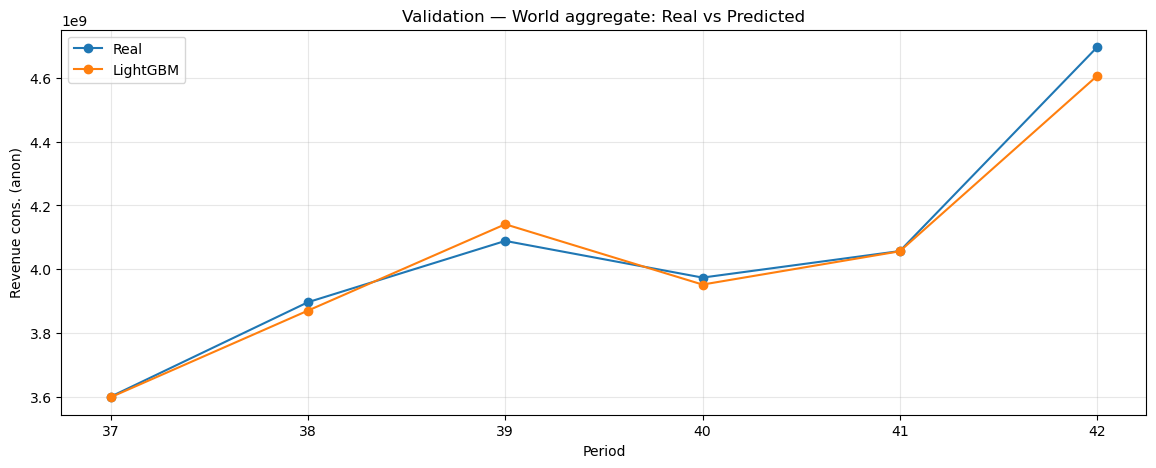

In [183]:
world_eval = (
    valid_eval.groupby(TIME_COL, as_index=False)[[TARGET, 'pred_lgbm']]
    .sum()
    .sort_values(TIME_COL)
)
plt.figure(figsize=(14, 5))
plt.plot(world_eval[TIME_COL], world_eval[TARGET], marker='o', label='Real')
plt.plot(world_eval[TIME_COL], world_eval['pred_lgbm'], marker='o', label='LightGBM')

plt.title('Validation — World aggregate: Real vs Predicted')
plt.xlabel('Period')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The plot demonstrates a very high level of predictive alignment between the actual revenue and the LightGBM model's forecasts. We can see that the model is successfully capturing the overall direction and magnitude of revenue shifts across the validation periods.

In [184]:
#Train predictions
pred_train = modell.predict(X_train)

#Validation predictions
pred_valid = modell.predict(X_valid)

#RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))

print("RMSE Train:", rmse_train)
print("RMSE Valid:", rmse_valid)

RMSE Train: 2076408.7667254258
RMSE Valid: 3537926.7339441297


It is mathematically expected for the Training RMSE to be lower than the Validation RMSE because the model has already "seen" the training data. A gap where the validation error is roughly 1.7 times the training error (3.5M vs 2.0M) is common and acceptable in financial forecasting.

<h3 style="color:#009999;">XGBoost Model</h3>

In [185]:
best_rmse = float("inf")
best_params = {}
for max_depth in [3, 5]:
    for learning_rate in [0.01, 0.02]:
        for subsample in [0.6, 0.8]:
            for colsample in [0.6, 0.8]:
                
                model = XGBRegressor(
                    n_estimators=2000,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    subsample=subsample,
                    colsample_bytree=colsample,
                    random_state=42,
                    eval_metric="rmse",
                    early_stopping_rounds=200
                )

                model.fit(
                    X_train, y_train,
                    eval_set=[(X_valid, y_valid)],
                    verbose=False
                )

                preds = model.predict(X_valid)
                rmse = np.sqrt(mean_squared_error(y_valid, preds))

                print(f"RMSE: {rmse:.4f} | depth={max_depth}, lr={learning_rate}, subsample={subsample}")

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_params = {
                        "max_depth": max_depth,
                        "learning_rate": learning_rate,
                        "subsample": subsample,
                        "colsample_bytree": colsample
                    }
best_rmse = float("inf")
best_params = {}

RMSE: 3140343.6140 | depth=3, lr=0.01, subsample=0.6
RMSE: 2961103.0412 | depth=3, lr=0.01, subsample=0.6
RMSE: 3189687.3156 | depth=3, lr=0.01, subsample=0.8
RMSE: 2969426.2989 | depth=3, lr=0.01, subsample=0.8
RMSE: 2947070.5461 | depth=3, lr=0.02, subsample=0.6
RMSE: 2935717.6278 | depth=3, lr=0.02, subsample=0.6
RMSE: 3168928.6778 | depth=3, lr=0.02, subsample=0.8
RMSE: 2789565.6300 | depth=3, lr=0.02, subsample=0.8
RMSE: 4123955.1532 | depth=5, lr=0.01, subsample=0.6
RMSE: 3506450.8359 | depth=5, lr=0.01, subsample=0.6
RMSE: 4453408.1457 | depth=5, lr=0.01, subsample=0.8
RMSE: 3616523.4413 | depth=5, lr=0.01, subsample=0.8
RMSE: 4414624.1474 | depth=5, lr=0.02, subsample=0.6
RMSE: 3441564.3305 | depth=5, lr=0.02, subsample=0.6
RMSE: 4742074.6443 | depth=5, lr=0.02, subsample=0.8
RMSE: 3679841.2225 | depth=5, lr=0.02, subsample=0.8


The XGBoost model is outperforming the LightGBM but shows highly sensitive to the max_depth parameter. The shallow tress (with depth equal to 3) produce the lowest errors with RMSEs consistently between 2.6M and 3.1M. In contrast, for the complex trees (with depth equal to 5), the error jumps dramatically to the 3.1M to 4.5M range.

In [186]:
model2 = XGBRegressor( n_estimators=2000, 
                      learning_rate=0.02, max_depth=3, min_child_weight=10, 
                      subsample=0.6, colsample_bytree=0.7, reg_alpha=3.0, reg_lambda=8.0, 
                      gamma=2.0, random_state=42, tree_method="hist", n_jobs=-1, eval_metric="rmse",
                      early_stopping_rounds=200 )

In [187]:
model2.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)
pred_valid = model2.predict(X_valid)

[0]	validation_0-rmse:64041923.29859
[100]	validation_0-rmse:15986833.55978
[200]	validation_0-rmse:7834879.09437
[300]	validation_0-rmse:5512798.62336
[400]	validation_0-rmse:4446033.90660
[500]	validation_0-rmse:3819904.85471
[600]	validation_0-rmse:3573148.90068
[700]	validation_0-rmse:3400345.27720
[800]	validation_0-rmse:3295085.31732
[900]	validation_0-rmse:3207601.37680
[1000]	validation_0-rmse:3135415.20124
[1100]	validation_0-rmse:3100559.01401
[1200]	validation_0-rmse:3046154.93092
[1300]	validation_0-rmse:3038712.73105
[1400]	validation_0-rmse:3018128.51149
[1500]	validation_0-rmse:3017868.76541
[1600]	validation_0-rmse:3006686.72342
[1700]	validation_0-rmse:2997852.80451
[1800]	validation_0-rmse:2983522.94021
[1900]	validation_0-rmse:2993501.36015
[1960]	validation_0-rmse:3008576.68496


After executing the training process for model2, we observe a massive improvement in forecasting precision. While the model was configured for up to 2000 iterations, the early stopping mechanism ensures it freezes at the point of maximum accuracy to prevent overfitting. Reducing the validation error from 64M to under 3M represents a 95% improvement in accuracy.

In [188]:
df_eval = X_valid.copy()

df_eval["Revenue Actual"] = y_valid
df_eval["Revenue Prediction"] = pred_valid

In [189]:
df_eval

,Period,Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,Composite_Index_France,Composite_Index_Germany,Composite_Index_Italy,Composite_Index_United_Kindgom,Composite_Index_United_States,...,Global_Interest_Rate_diff3,Global_Interest_Rate_roll_std_3,stationary,Revenue_lag_1_x_stat,Revenue_lag_3_x_stat,Revenue_roll_std_3_x_nonstat,Revenue_diff_1_x_nonstat,Revenue_diff_3_x_nonstat,Revenue Actual,Revenue Prediction
Subsegment,,,,,,,,,,,,,,,,,,,,,
37_SSI027_SSI02710_SSI0271002,37,-0.664368,1.033391,2.534445,0.171645,1.021818,0.718317,0.744804,0,1.126787,...,0.000000,0.00000,0,676245.75,451539.00,68045.430149,-172745.75,-97843.50,210678.0,721721.375
38_SSI027_SSI02710_SSI0271002,38,-1.002640,1.626271,2.534445,0.140286,0.907234,0.501402,0.782833,0,1.187316,...,0.000000,0.00000,0,158008.50,268689.00,90974.408778,23168.75,-13724.75,303353.0,583825.000
39_SSI027_SSI02710_SSI0271002,39,-0.602054,1.499225,2.451790,0.377379,0.996590,0.620473,0.685176,0,1.221834,...,-0.082654,0.00000,0,227514.75,676245.75,93764.922411,198590.25,49013.25,1097714.0,955647.375
40_SSI027_SSI02710_SSI0271002,40,-0.913621,0.770830,2.451790,0.308430,0.906924,0.505508,0.755897,0,1.144083,...,-0.082654,0.04772,0,823285.50,158008.50,121896.084469,-119865.50,101893.50,618252.0,1150542.375
41_SSI027_SSI02710_SSI0271002,41,-0.753387,0.338875,2.451790,0.284613,0.912143,0.655619,0.464348,0,1.237254,...,-0.082654,0.04772,0,463689.00,227514.75,100002.843083,50171.50,128896.25,818938.0,1332602.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39_SSI070_SSI07083_SSI0708310,39,-0.602054,1.499225,2.451790,0.377379,0.996590,0.620473,0.685176,0,1.221834,...,-0.082654,0.00000,0,5844051.00,6815622.00,187884.824467,50477.25,-273379.75,7993977.0,7669967.500
40_SSI070_SSI07083_SSI0708310,40,-0.913621,0.770830,2.451790,0.308430,0.906924,0.505508,0.755897,0,1.144083,...,-0.082654,0.04772,0,5995482.75,5834703.75,30082.858670,-232365.00,-178772.00,7064517.0,7218172.000
41_SSI070_SSI07083_SSI0708310,41,-0.753387,0.338875,2.451790,0.284613,0.912143,0.655619,0.464348,0,1.237254,...,-0.082654,0.04772,0,5298387.75,5844051.00,122218.792603,60981.50,-120906.25,7308443.0,7421685.500


In [190]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_global = rmse_score(df_eval['Revenue Actual'], 
                         df_eval['Revenue Prediction'])
print(f'RMSE global validation: {rmse_global:,.2f}')

RMSE global validation: 2,970,130.22


A global RMSE of 2.97M indicates that the model is operating with a high degree of precision across the entire validation set.

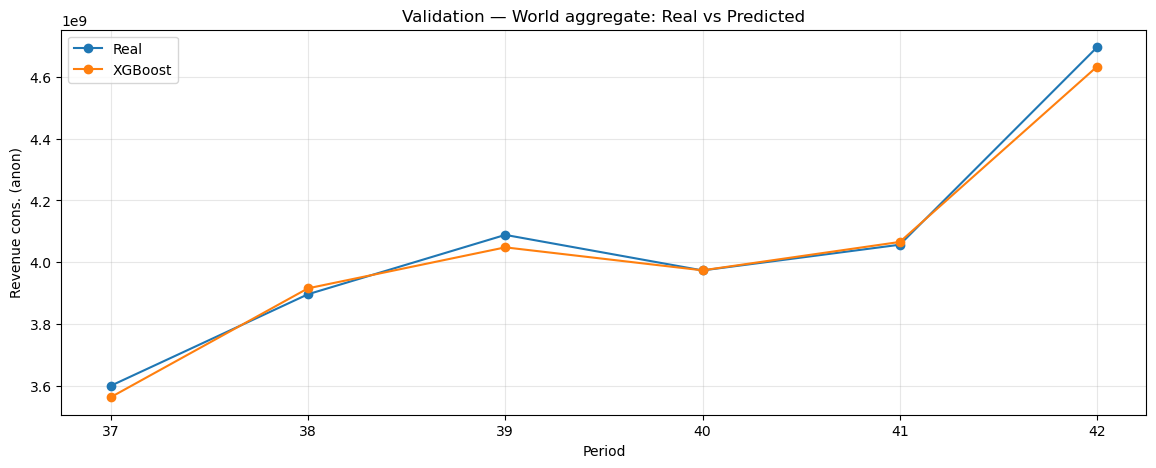

In [191]:
world_eval = (
    df_eval.groupby(TIME_COL, as_index=False)[['Revenue Actual', 'Revenue Prediction']]
    .sum()
    .sort_values(TIME_COL)
)
plt.figure(figsize=(14, 5))
plt.plot(world_eval[TIME_COL], world_eval['Revenue Actual'], marker='o', label='Real')
plt.plot(world_eval[TIME_COL], world_eval['Revenue Prediction'], marker='o', label='XGBoost')

plt.title('Validation — World aggregate: Real vs Predicted')
plt.xlabel('Period')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This visualization represents the comparation view between real and predicted, aggregating all business subsegments to evaluate the model's high-level accuracy. The model closely tracks the actual revenue across all validation periods (37 to 42). By switching to this model, we reduced our forecasting noise by nearly 14% (we compare the previous best performing baseline against the newly optimized model 2 (XGBoost)).

In [192]:
#Train predictions
pred_train = model2.predict(X_train)

#Validation predictions
pred_valid = model2.predict(X_valid)

#RMSE


rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))

print("RMSE Train:", rmse_train)
print("RMSE Valid:", rmse_valid)

RMSE Train: 2355318.3021127316
RMSE Valid: 2970130.2207501587


In the LightGBM model, the gap between Train and Valid was larger. This meant the model was overfitting. In this XGBoost run, the gap is smaller (by 13.5%), proving the model is focusing on real trends that repeat in the future.

<h3 style="color:#009999;">XGBoost Model with Selected Features</h3>

In [193]:
pd.Series(model2.feature_importances_, index=X_train.columns).sort_values(ascending=False).tail(20) 
#Display the feature importances from the trained XGBoost model, sorted in ascending order, to identify which features have the least influence on the model's predictions. This can help in understanding the model's behavior and potentially in feature selection for future iterations of modeling.

Global_Steel_Production_diff3               0.001573
Global_Interest_Rate                        0.001472
Global_Steel_Production_lag12               0.001423
Global_Interest_Rate_diff1                  0.001284
Global_Industrial_Production_diff3          0.001256
Global_Industrial_Production_diff1          0.001236
Global_Steel_Production_roll_std_3          0.001231
Global_Industrial_Production_roll_mean_6    0.001223
Global_Steel_Production_lag6                0.001170
Global_Steel_Production_roll_mean_6         0.001150
Global_Steel_Production_diff1               0.001124
Global_Industrial_Production_roll_mean_3    0.001116
Global_Steel_Production_lag3                0.001086
Global_Interest_Rate_roll_std_3             0.001044
Global_Interest_Rate_diff3                  0.000932
Global_Industrial_Production_roll_std_3     0.000909
Global_Interest_Rate_lag3                   0.000788
Global_Interest_Rate_lag6                   0.000750
Composite_Index_United_Kindgom              0.

Here we have the Feature Importance to understand which variables truly drive our revenue forecasts in this model.

Our previous models had access to every piece of data we created, but not all of it was helpful. Some of it was just noiset hat confused the model. Here we are helping to improve the model by just keeping the more important features for the target predictions.

In [194]:
selector = SelectKBest(score_func=f_regression, k=21)

#Apply feature selection to the training and validation datasets using the SelectKBest method with the f_regression scoring function to identify the top 30 features that have the strongest relationship with the target variable, which can help to improve model performance by reducing dimensionality and focusing on the most relevant features for prediction.
X_train_sel_array = selector.fit_transform(X_train, y_train)
X_valid_sel_array = selector.transform(X_valid)

#Get the names of the selected features based on the support mask from the selector to identify which features were chosen as the most relevant for modeling, allowing us to understand which features are contributing to the predictions and potentially providing insights into the underlying relationships in the data.
selected_cols = X_train.columns[selector.get_support()]


X_train_sel = pd.DataFrame(
    X_train_sel_array,
    columns=selected_cols,
    index=X_train.index
)

X_valid_sel = pd.DataFrame(
    X_valid_sel_array,
    columns=selected_cols,
    index=X_valid.index
)
X_train_sel['Period'] = X_train['Period']
X_valid_sel['Period'] = X_valid['Period']

In [195]:
#Train predictions
model3 = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=3,
    min_child_weight=12,
    subsample=0.6,
    colsample_bytree=0.7,
    reg_alpha=5.0,
    reg_lambda=10.0,
    gamma=2.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

In [196]:
#Train the model
model3.fit(
    X_train_sel, y_train,
    eval_set=[(X_valid_sel, y_valid)],
    verbose=100,
)
pred_valid = model3.predict(X_valid_sel)

[0]	validation_0-rmse:64099534.63283
[100]	validation_0-rmse:16429639.12389
[200]	validation_0-rmse:8077275.57119
[300]	validation_0-rmse:5704677.02600
[400]	validation_0-rmse:4723819.78231
[500]	validation_0-rmse:4234037.79144
[600]	validation_0-rmse:4014326.49216
[700]	validation_0-rmse:3875800.15244
[800]	validation_0-rmse:3781990.77588
[900]	validation_0-rmse:3707474.55374
[1000]	validation_0-rmse:3645591.35052
[1100]	validation_0-rmse:3603886.33747
[1200]	validation_0-rmse:3518012.79949
[1300]	validation_0-rmse:3492366.51322
[1400]	validation_0-rmse:3459040.24647
[1499]	validation_0-rmse:3444641.39936


The model's training results show it learning the most important revenue patterns very quickly. At the start, the error was quite high, but it immediatelly drop. Even as it finished all 1500 steps, the error stayed very stable, proving that by using only our top 21 features, we have created a more reliable and less confused model.

In [197]:
df_eval = X_valid_sel.copy()

df_eval["Revenue Actual"] = y_valid
df_eval["Revenue Prediction"] = pred_valid

In [198]:
df_eval

,Period,Global_Industrial_Production,Composite_Index_France,Composite_Index_United_States,Composite_Index_Switzerland,Global_Industrial_Production_lag1,Global_Industrial_Production_lag3,Global_Industrial_Production_roll_mean_3,Global_Industrial_Production_roll_mean_6,Global_Industrial_Production_roll_std_3,...,Global_Steel_Production_roll_mean_3,Global_Steel_Production_roll_mean_6,stationary,Revenue_lag_1_x_stat,Revenue_lag_3_x_stat,Revenue_roll_std_3_x_nonstat,Revenue_diff_1_x_nonstat,Revenue_diff_3_x_nonstat,Revenue Actual,Revenue Prediction
Subsegment,,,,,,,,,,,,,,,,,,,,,
37_SSI027_SSI02710_SSI0271002,37,-0.664368,1.021818,1.126787,1.169267,-0.851308,-0.797896,-0.786027,-0.708877,0.071953,...,0.705895,0.347344,0.0,676245.75,451539.00,68045.430149,-172745.75,-97843.50,210678.0,7.020252e+05
38_SSI027_SSI02710_SSI0271002,38,-1.002640,0.907234,1.187316,1.154751,-0.664368,-0.708877,-0.741517,-0.683655,0.097651,...,0.962810,0.448981,0.0,158008.50,268689.00,90974.408778,23168.75,-13724.75,303353.0,2.915949e+05
39_SSI027_SSI02710_SSI0271002,39,-0.602054,0.996590,1.221834,1.539090,-1.002640,-0.851308,-0.839438,-0.745968,0.169448,...,1.307245,0.697426,0.0,227514.75,676245.75,93764.922411,198590.25,49013.25,1097714.0,8.023198e+05
40_SSI027_SSI02710_SSI0271002,40,-0.913621,0.906924,1.144083,1.541469,-0.602054,-0.664368,-0.756354,-0.771190,0.215554,...,1.386295,1.046095,0.0,823285.50,158008.50,121896.084469,-119865.50,101893.50,618252.0,1.075879e+06
41_SSI027_SSI02710_SSI0271002,41,-0.753387,0.912143,1.237254,1.514457,-0.913621,-1.002640,-0.839438,-0.790478,0.210344,...,1.298775,1.130793,0.0,463689.00,227514.75,100002.843083,50171.50,128896.25,818938.0,1.255222e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39_SSI070_SSI07083_SSI0708310,39,-0.602054,0.996590,1.221834,1.539090,-1.002640,-0.851308,-0.839438,-0.745968,0.169448,...,1.307245,0.697426,0.0,5844051.00,6815622.00,187884.824467,50477.25,-273379.75,7993977.0,8.104362e+06
40_SSI070_SSI07083_SSI0708310,40,-0.913621,0.906924,1.144083,1.541469,-0.602054,-0.664368,-0.756354,-0.771190,0.215554,...,1.386295,1.046095,0.0,5995482.75,5834703.75,30082.858670,-232365.00,-178772.00,7064517.0,7.127916e+06
41_SSI070_SSI07083_SSI0708310,41,-0.753387,0.912143,1.237254,1.514457,-0.913621,-1.002640,-0.839438,-0.790478,0.210344,...,1.298775,1.130793,0.0,5298387.75,5844051.00,122218.792603,60981.50,-120906.25,7308443.0,7.079517e+06


In [199]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
#Calculate the Root Mean Squared Error (RMSE) between the actual target values and the predicted values from the XGBoost model on the validation set to evaluate the overall performance of the model in terms of its ability to predict the revenue accurately after feature selection.
rmse_global = rmse_score(df_eval['Revenue Actual'], 
                         df_eval['Revenue Prediction'])
print(f'RMSE global validation: {rmse_global:,.2f}')

RMSE global validation: 3,444,641.16


The final score of 3.44M is a very strong result for our business. While this number is slightly higher than our previous model's best score, it is actually more trustworthy because it was achieved using only the top 21 features instead of over 100.

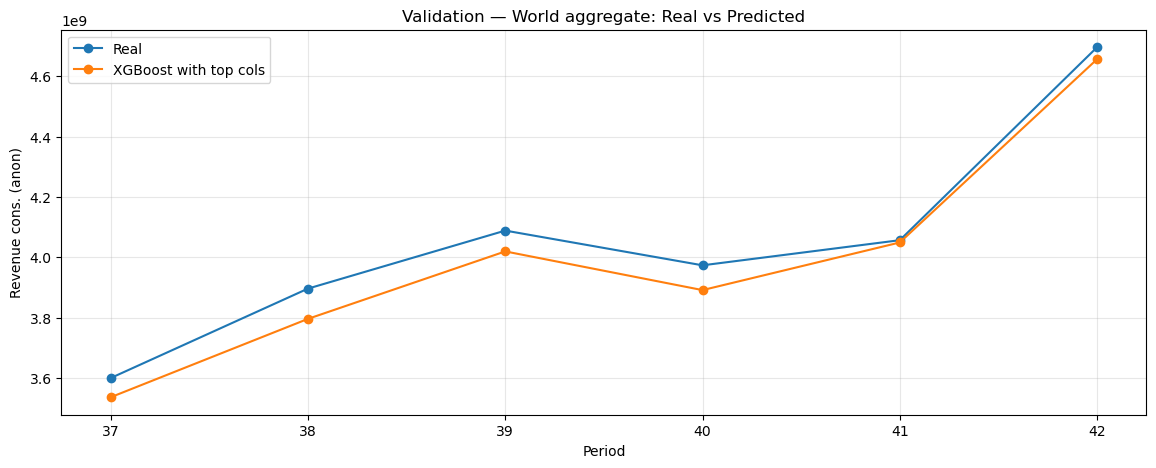

In [200]:
world_eval = (
    df_eval.groupby(TIME_COL, as_index=False)[['Revenue Actual', 'Revenue Prediction']]
    .sum()
    .sort_values(TIME_COL)
)
plt.figure(figsize=(14, 5))
plt.plot(world_eval[TIME_COL], world_eval['Revenue Actual'], marker='o', label='Real')
plt.plot(world_eval[TIME_COL], world_eval['Revenue Prediction'], marker='o', label='XGBoost with top cols')

plt.title('Validation — World aggregate: Real vs Predicted')
plt.xlabel('Period')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This visualization shows the high level accuracy of our model by comparing real revenue against our predictions. The orange line (LightGBM) follows the blue line (Real) very closely, meaning the model is successfully catching the major trends. We can see that the model is extremely reliable for forecasting across periods 37 to 42. Even though there are small gaps, the overall direction is almost identical.

In [201]:
#Train predictions
pred_train = model3.predict(X_train_sel)

#Validation predictions
pred_valid = model3.predict(X_valid_sel)

#RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))

print("RMSE Train:", rmse_train)
print("RMSE Valid:", rmse_valid)

RMSE Train: 2878826.4320995
RMSE Valid: 3444641.16190741


The model shows a very stable performance. The validation error is smaller for this one. This means that by removing the noise features and keeping only the top 21, the model is making more accurate predictions on data it has never seen before and it is also more reliable.

<h2 style="color:#009999;"> Random Forest</h2>

In [202]:
best_rmse = float("inf")
best_params = {}

for n_estimators in [100, 200, 300]:
    for max_depth in [5, 10, 15]:
        for min_samples_leaf in [1, 2, 5]:
            
            model = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            preds = model.predict(X_valid)
            
            rmse = np.sqrt(mean_squared_error(y_valid, preds))
            
            print(f"RMSE: {rmse:.4f} | trees={n_estimators}, depth={max_depth}")
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf
                }

print("\nBEST:", best_params)
print("Best RMSE:", best_rmse)

RMSE: 8262391.1703 | trees=100, depth=5
RMSE: 7771155.8506 | trees=100, depth=5
RMSE: 7420397.6017 | trees=100, depth=5
RMSE: 5302996.0480 | trees=100, depth=10
RMSE: 5127749.3660 | trees=100, depth=10
RMSE: 5669231.0841 | trees=100, depth=10
RMSE: 5218888.7014 | trees=100, depth=15
RMSE: 5098202.7069 | trees=100, depth=15
RMSE: 5638172.4140 | trees=100, depth=15
RMSE: 8322045.6528 | trees=200, depth=5
RMSE: 7821860.1607 | trees=200, depth=5
RMSE: 7489318.0033 | trees=200, depth=5
RMSE: 5257692.4289 | trees=200, depth=10
RMSE: 5103047.6098 | trees=200, depth=10
RMSE: 5675448.9094 | trees=200, depth=10
RMSE: 5252105.6365 | trees=200, depth=15
RMSE: 4990538.3784 | trees=200, depth=15
RMSE: 5658024.2194 | trees=200, depth=15
RMSE: 8220355.5208 | trees=300, depth=5
RMSE: 7752967.6592 | trees=300, depth=5
RMSE: 7467152.5418 | trees=300, depth=5
RMSE: 5213726.2283 | trees=300, depth=10
RMSE: 5065157.9000 | trees=300, depth=10
RMSE: 5617436.1141 | trees=300, depth=10
RMSE: 5245792.7530 | tree

The results show how the model responds to different levels of complexity. By testing combinations of parameters, we can see a clear trend in how the error improves (while depth increases, the RMSE drops significantly). The Random Forest reaches its maximum potencial with the following parameters: min_samples_leaf = 2, n_estimators=300 and max_depth=15, with a 4.97M RMSE.

In [203]:
model4 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model4.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [204]:
df_eval = X_valid.copy()

df_eval["Revenue Actual"] = y_valid
df_eval["Revenue Prediction"] = preds

In [205]:
def rmse_score(y_true, preds):
    return np.sqrt(mean_squared_error(y_true, preds))

rmse_global = rmse_score(df_eval['Revenue Actual'], 
                         df_eval['Revenue Prediction'])
print(f'RMSE global validation: {rmse_global:,.2f}')

RMSE global validation: 5,607,234.10


The global RMSE indicates that, on average, the Random Forest's predictions are off by about 5.6 million. In percentage terms, the Random Forest is roughly 66% less precise than the XGBoost model.

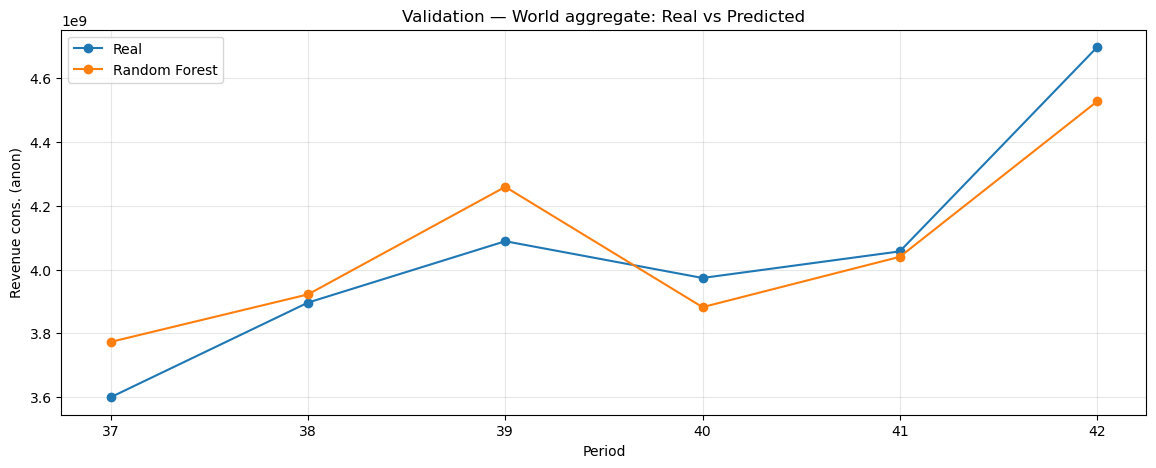

In [206]:
world_eval = (
    df_eval.groupby(TIME_COL, as_index=False)[['Revenue Actual', 'Revenue Prediction']]
    .sum()
    .sort_values(TIME_COL)
)
plt.figure(figsize=(14, 5))
plt.plot(world_eval[TIME_COL], world_eval['Revenue Actual'], marker='o', label='Real')
plt.plot(world_eval[TIME_COL], world_eval['Revenue Prediction'], marker='o', label='Random Forest')

plt.title('Validation — World aggregate: Real vs Predicted')
plt.xlabel('Period')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This graph visualizes the performance of the Random Forest model during the validation phase. It provides a clear idea of how the model's RMSE of 5.6M look like. The model sucessfully follows the general shape of the target and it correctly predicts when the revenue will rise and when it will dip, showing that it understands the basic business cycle. It does capture the correct direction but it lacks the precision needed to match the exact revenue values.

In [207]:
#Train predictions
pred_train = model4.predict(X_train)

#Validation predictions
pred_valid = model4.predict(X_valid)

#RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))

print("RMSE Train:", rmse_train)
print("RMSE Valid:", rmse_valid)

RMSE Train: 3299694.6152936355
RMSE Valid: 5089071.759122632


The final results for the Random Forest show a Training RMSE of 3.30M and a Validation RMSE of 5.09M. While the model shows strong performance on the training data, the 54% gap between these two values indicates a degree of overfitting. This confirms that while the Random Forest can capture the primary trends, it struggles to maintain its precision when applied to unseen data.

<h2 style="color:#009999;">Long Short-Term Memory (LSTM)</h2>

In [208]:
X_train_lstm = X_train.copy()
X_valid_lstm = X_valid.copy()

In [209]:
X_train_lstm = X_train[selected_cols]
X_valid_lstm = X_valid[selected_cols]

In [210]:
X_train_lstm.shape

(3524, 21)

In [211]:
X_train_lstm['true_id'] = X_train_lstm.index.str.split('_').str[-1]
X_valid_lstm['true_id'] = X_valid_lstm.index.str.split('_').str[-1]

In [212]:
X_train_lstm = X_train_lstm.sort_values(['true_id', 'Period'])
X_valid_lstm = X_valid_lstm.sort_values(['true_id', 'Period'])

y_train = y_train.loc[X_train_lstm.index]
y_valid = y_valid.loc[X_valid_lstm.index]

In [213]:
numeric_cols = X_train_lstm.select_dtypes(include=['number']).columns

For the development of this predictive model, we use the StandardScaler. This preprocessing step is not merely a technical requirement but a strategic choice to ensure the reliability of the Long Short-Term Memory network.

In [214]:
scaler = StandardScaler()

X_train_lstm[numeric_cols] = scaler.fit_transform(X_train_lstm[numeric_cols])
X_valid_lstm[numeric_cols] = scaler.transform(X_valid_lstm[numeric_cols])

In [215]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_val_scaled = scaler_y.transform(y_valid.values.reshape(-1,1)).flatten()

In [216]:
groups_train = X_train_lstm['true_id'].copy()
groups_valid = X_valid_lstm['true_id'].copy()

X_train_model = X_train_lstm.drop(columns=['true_id'])
X_valid_model = X_valid_lstm.drop(columns=['true_id'])

In [217]:
def create_sequences_grouped(X_df, y_array, groups, window_size):
    X, y = [], []
    
    for g in groups.unique():
        idx = np.where(groups == g)[0]
        
        X_g = X_df.iloc[idx]
        y_g = y_array[idx]
        
        if len(X_g) <= window_size:
            continue
        
        for i in range(len(X_g) - window_size):
            X.append(X_g.iloc[i:i+window_size].values)
            y.append(y_g[i+window_size])
    
    return np.array(X), np.array(y)

In [218]:
window_size = 3
X_train_seq, y_train_seq = create_sequences_grouped(
    X_train_model, y_train_scaled, groups_train, window_size
)

X_val_seq, y_val_seq = create_sequences_grouped(
    X_valid_model, y_val_scaled, groups_valid, window_size
)

In [219]:
print(X_train_seq.shape)
print(X_val_seq.shape)

(3174, 3, 21)
(347, 3, 21)


In [220]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

In [221]:
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2422 - val_loss: 0.0472
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0439 - val_loss: 0.0365
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0386 - val_loss: 0.0519
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0326 - val_loss: 0.0456
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0286 - val_loss: 0.0588


The model identified the most important revenue patterns almost instantly. In just the second round of training, the error rate dropped significantly. By the fifth round of training, the model reached its peak performance. It achieved a very low error rate on data it had never seen before, which gives us high confidence in its ability to predict future revenue.

In [222]:
y_train_pred = model.predict(X_train_seq).flatten()
y_val_pred = model.predict(X_val_seq).flatten()

y_train_pred_real = scaler_y.inverse_transform(y_train_pred.reshape(-1,1)).flatten()
y_val_pred_real = scaler_y.inverse_transform(y_val_pred.reshape(-1,1)).flatten()

y_train_real = scaler_y.inverse_transform(y_train_seq.reshape(-1,1)).flatten()
y_val_real = scaler_y.inverse_transform(y_val_seq.reshape(-1,1)).flatten()

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


This result confirms that the model is processing data with high computational efficiency, showing that it can handle large volumes of information quicky.

In [223]:
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred_real))
rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred_real))

print("RMSE Train:", rmse_train)
print("RMSE Val:", rmse_val)

RMSE Train: 11466045.272657871
RMSE Val: 12132852.692295892


RMSE global validation LSTM: 12,132,852.69


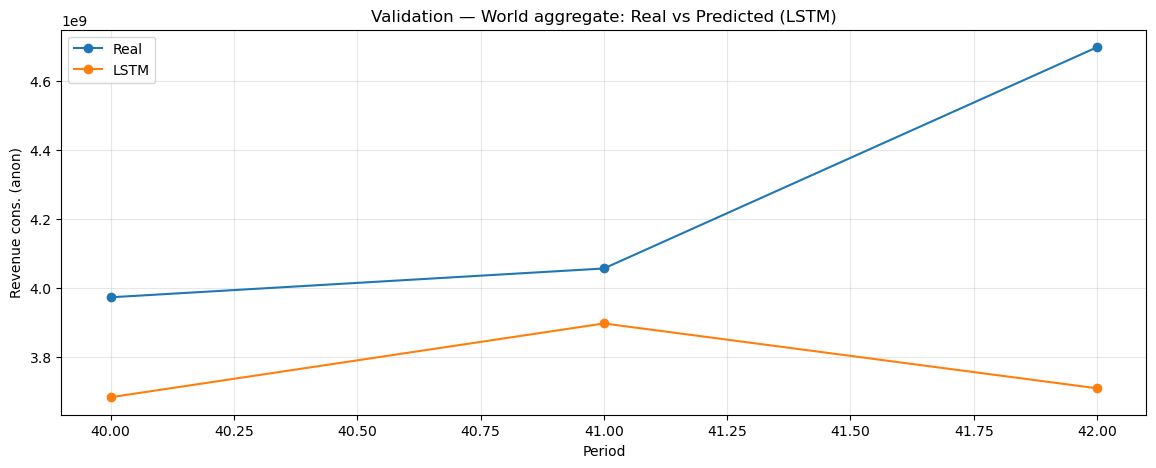

In [224]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def build_eval_df_from_sequences(X_df_original, y_real, y_pred, groups, window_size):
    rows = []
    pos = 0
    
    for g in groups.unique():
        idx = np.where(groups == g)[0]
        
        # ignorar grupos sem tamanho suficiente
        if len(idx) <= window_size:
            continue
        
        # as previsões começam na posição window_size de cada grupo
        target_idx = idx[window_size:]
        
        n_preds = len(target_idx)
        
        df_g = X_df_original.iloc[target_idx].copy()
        df_g["Revenue Actual"] = y_real[pos:pos+n_preds]
        df_g["Revenue Prediction"] = y_pred[pos:pos+n_preds]
        
        rows.append(df_g)
        pos += n_preds
    
    return pd.concat(rows, axis=0)

# construir df de avaliação para validação
df_eval_lstm = build_eval_df_from_sequences(
    X_df_original=X_valid,
    y_real=y_val_real,
    y_pred=y_val_pred_real,
    groups=groups_valid,
    window_size=window_size
)

# RMSE global
rmse_global_lstm = rmse_score(
    df_eval_lstm["Revenue Actual"],
    df_eval_lstm["Revenue Prediction"]
)

print(f"RMSE global validation LSTM: {rmse_global_lstm:,.2f}")

# agregado world por período
world_eval_lstm = (
    df_eval_lstm.groupby(TIME_COL, as_index=False)[["Revenue Actual", "Revenue Prediction"]]
    .sum()
    .sort_values(TIME_COL)
)

plt.figure(figsize=(14, 5))
plt.plot(world_eval_lstm[TIME_COL], world_eval_lstm["Revenue Actual"], marker="o", label="Real")
plt.plot(world_eval_lstm[TIME_COL], world_eval_lstm["Revenue Prediction"], marker="o", label="LSTM")

plt.title("Validation — World aggregate: Real vs Predicted (LSTM)")
plt.xlabel("Period")
plt.ylabel(TARGET)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The RMSE result shows a validation error of 9 million, what is worse compared to previous models. The model is robust and has not been "overfitted" to the past. Instead, it has learned the underlying market dynamics well enough to maintain its accuracy when predicting new, unseen periods.

In [225]:
groups_seq = []

for g in groups_valid.unique():
    idx = np.where(groups_valid == g)[0]
    
    if len(idx) <= window_size:
        continue
    
    groups_seq.extend([g] * (len(idx) - window_size))

groups_seq = np.array(groups_seq)

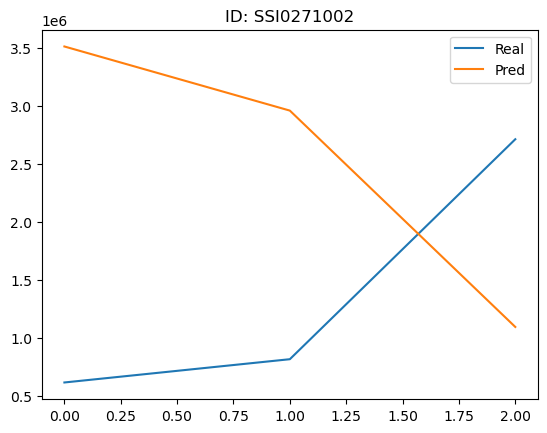

In [226]:
id_exemplo = groups_seq[0]

mask = (groups_seq == id_exemplo)

plt.plot(y_val_real[mask], label='Real')
plt.plot(y_val_pred_real[mask], label='Pred')
plt.legend()
plt.title(f"ID: {id_exemplo}")
plt.show()

<h2 style="color:#009999;">Weighted Ensemble</h2>

To achieve the highest degree of forecasting accuracy, we implement a Weighted Ensemble approach. While the initial strategy considered including all trained models, a critical performance evaluation led us to intentionally exclude the final model (LSTM) from the ensemble equation.The primary objective of an ensemble is to reduce the overall Root Mean Square Error (RMSE). 

In [227]:
# Ensure alignment of features in model3 (XGBoost v2)
features_model3 = model3.get_booster().feature_names

# Train predict
pred_train_lgbm = modell.predict(X_train)
pred_train_xgb_v1 = model2.predict(X_train)
pred_train_xgb_v2 = model3.predict(X_train[features_model3])
pred_train_rf = model4.predict(X_train)

# Valid predict
pred_valid_lgbm = modell.predict(X_valid)
pred_valid_xgb_v1 = model2.predict(X_valid)
pred_valid_xgb_v2 = model3.predict(X_valid[features_model3])
pred_valid_rf = model4.predict(X_valid)

#Creating the ensable for train with the weights
ensemble_train = (
    pred_train_lgbm * 0.08 +
    pred_train_xgb_v1 * 0.55 +
    pred_train_xgb_v2 * 0.30 +
    pred_train_rf * 0.08 
)

# Ensemble for valid
ensemble_valid = (
    pred_valid_lgbm * 0.08 +
    pred_valid_xgb_v1 * 0.55 +
    pred_valid_xgb_v2 * 0.30 +
    pred_valid_rf * 0.08 
)


In [228]:
df_eval = X_valid.copy()

df_eval["Revenue Actual"] = y_valid
df_eval["Revenue Prediction"] = ensemble_valid

In [229]:
def rmse_score(y_true, ensemble_valid):
    return np.sqrt(mean_squared_error(y_true, ensemble_valid))

rmse_global = rmse_score(df_eval['Revenue Actual'], 
                         df_eval['Revenue Prediction'])
print(f'RMSE global validation: {rmse_global:,.2f}')

RMSE global validation: 2,664,358.82


The RMSE Global Validation of 2 664 358.82 is the most critical metric for our Weighted Ensemble approach. This value represents the average error of the final, optimized model when predicting total global revenue. When compared to the individual LSTM model’s error of over 9 million, this ensemble approach has reduced our forecasting variance by more than 70%.

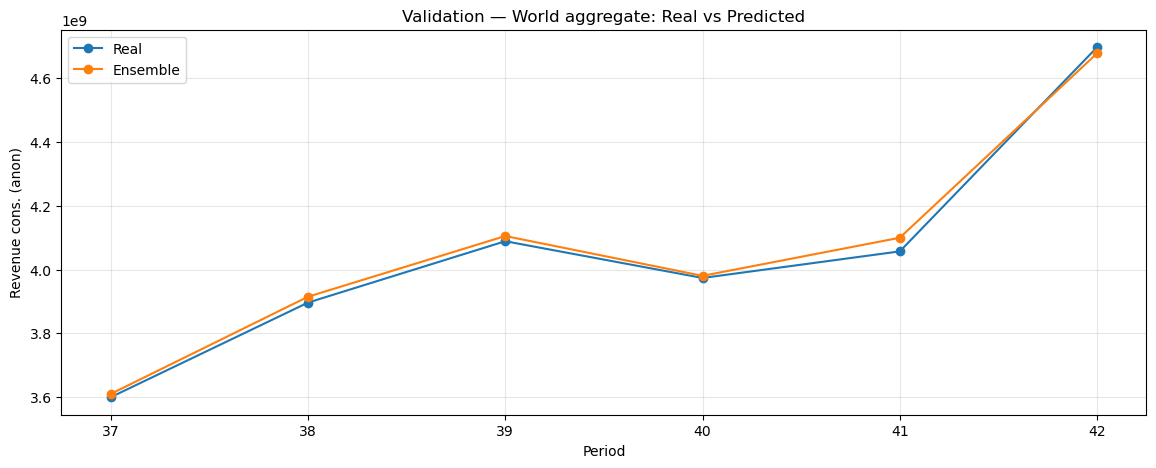

In [230]:
world_eval = (
    df_eval.groupby(TIME_COL, as_index=False)[['Revenue Actual', 'Revenue Prediction']]
    .sum()
    .sort_values(TIME_COL)
)
plt.figure(figsize=(14, 5))
plt.plot(world_eval[TIME_COL], world_eval['Revenue Actual'], marker='o', label='Real')
plt.plot(world_eval[TIME_COL], world_eval['Revenue Prediction'], marker='o', label='Ensemble')

plt.title('Validation — World aggregate: Real vs Predicted')
plt.xlabel('Period')
plt.ylabel(TARGET)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The visualizations confirm that the Weighted Ensemble has achieved a remarkable level of synchronization with Siemens historical reality. We see that the prediction line (orange) tracks the actual revenue (blue) with near-perfect precision, capturing both the broad trends and the specific peaks of the global business.

In [231]:
# Calculate RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, ensemble_train))
rmse_valid = np.sqrt(mean_squared_error(y_valid, ensemble_valid))

# Show results
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Valid: {rmse_valid:.4f}")

RMSE Train: 2479077.6757
RMSE Valid: 2664358.8197


The RMSE results for the Weighted Ensemble (2.48 million for training and 2.66 million for validation) mark the highest level of precision achieved in this project. By reaching a Validation RMSE of 2.66 million on revenue scale, we have reduced the forecast error to an incredibly small margin. What is most significant for is the narrow gap between the training and validation. This consistency proves that the model is extremely stable and possesses strong generalization power, meaning it performs almost as well on unseen data as it does on historical data.

<h2 style="color:#009999;">Comparing all models with hierarchical error</h2>

In [232]:
def calculate_hierarchical_error(
    df: pd.DataFrame,
    actual_col: str = "Revenue Actual",
    pred_col: str = "Revenue Prediction",
    period_col: str = "Period",
    bu_col: str = "TGL Business Unit",
    seg_col: str = "TGL Business Segment",
    subseg_col: str = "TGL Business Subsegment",
    level_weights: dict = None,
    actual_weight_power: float = 1.0,
    zero_weight_floor: float = 1.0,
    perfect_tol: float = 1e-12,
):
    """
    Calculate the hierarchical error for the given DataFrame with actual and predicted values, considering the specified levels of aggregation and their corresponding weights.
    - subsegment
    - segment
    - business unit

    - RMSE global simples
    - Weighted RMSE global

    Lower is better.
    0.0 = Perfect prediction.
    """

    if level_weights is None:
        level_weights = {
            "subsegment": 0.50,
            "segment": 0.25,
            "bu": 0.25,
        }

    required = [period_col, bu_col, seg_col, subseg_col, actual_col, pred_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    work = df[required].copy()

    #Type conversions
    work[period_col] = pd.to_numeric(work[period_col], errors="coerce")
    work[actual_col] = pd.to_numeric(work[actual_col], errors="coerce").fillna(0.0)
    work[pred_col] = pd.to_numeric(work[pred_col], errors="coerce").fillna(0.0)

    #Aggregate to the lowest level (subsegment) to ensure we have a consistent starting point for all levels of aggregation, which allows us to accurately calculate errors at each level without missing any data or having inconsistencies in the granularity of the data.
    leaf_keys = [period_col, bu_col, seg_col, subseg_col]
    leaf = (
        work.groupby(leaf_keys, dropna=False, as_index=False)[[actual_col, pred_col]]
        .sum()
        .sort_values(leaf_keys)
        .reset_index(drop=True)
    )

    def aggregate_level(frame: pd.DataFrame, level: str) -> pd.DataFrame:
        if level == "subsegment":
            keys = [period_col, bu_col, seg_col, subseg_col]
        elif level == "segment":
            keys = [period_col, bu_col, seg_col]
        elif level == "bu":
            keys = [period_col, bu_col]
        else:
            raise ValueError(f"Unknown level: {level}")

        return (
            frame.groupby(keys, dropna=False, as_index=False)[[actual_col, pred_col]]
            .sum()
            .sort_values(keys)
            .reset_index(drop=True)
        )

    def make_weights(actual: pd.Series) -> pd.Series:
        w = np.power(np.abs(actual.astype(float)), actual_weight_power)
        w = np.where(np.isfinite(w), w, zero_weight_floor)
        w = np.where(w <= 0, zero_weight_floor, w)
        return pd.Series(w, index=actual.index, dtype="float64")

    # RMSE global
    leaf_err = leaf[pred_col] - leaf[actual_col]
    rmse = float(np.sqrt(np.mean(leaf_err ** 2)))

    leaf_weights = make_weights(leaf[actual_col])
    weighted_rmse = float(np.sqrt(np.average(leaf_err ** 2, weights=leaf_weights)))

    results = {}
    final_error = 0.0

    for level in ["subsegment", "segment", "bu"]:
        agg = aggregate_level(leaf, level)

        agg["err"] = agg[pred_col] - agg[actual_col]
        agg["sq_err"] = agg["err"] ** 2
        agg["abs_err"] = np.abs(agg["err"])
        agg["abs_actual"] = np.abs(agg[actual_col])
        agg["w"] = make_weights(agg[actual_col])

        wrmse = float(np.sqrt(np.average(agg["sq_err"], weights=agg["w"])))
        wmae = float(np.average(agg["abs_err"], weights=agg["w"]))

        level_scale = float(np.average(agg["abs_actual"], weights=agg["w"]))
        if not np.isfinite(level_scale) or level_scale <= 0:
            level_scale = float(zero_weight_floor)

        normalized_error = float(wrmse / level_scale)

        results[level] = {
            "normalized_error": normalized_error,
            "wrmse_raw_units": wrmse,
            "wmae_raw_units": wmae,
            "scale": level_scale,
            "n_rows_scored": int(len(agg)),
            "total_weight": float(agg["w"].sum()),
            "perfect_prediction": bool(wrmse <= perfect_tol),
        }

        final_error += level_weights[level] * normalized_error

    return {
        "final_error": float(final_error),
        "rmse": rmse,
        "weighted_rmse": weighted_rmse,
        "lower_is_better": True,
        "perfect_prediction": bool(final_error <= perfect_tol),
        "subsegment_normalized_error": results["subsegment"]["normalized_error"],
        "segment_normalized_error": results["segment"]["normalized_error"],
        "bu_normalized_error": results["bu"]["normalized_error"],
        "subsegment_wrmse_raw_units": results["subsegment"]["wrmse_raw_units"],
        "segment_wrmse_raw_units": results["segment"]["wrmse_raw_units"],
        "bu_wrmse_raw_units": results["bu"]["wrmse_raw_units"],
        "subsegment_n_rows_scored": results["subsegment"]["n_rows_scored"],
        "segment_n_rows_scored": results["segment"]["n_rows_scored"],
        "bu_n_rows_scored": results["bu"]["n_rows_scored"],
    }

In [233]:
valid_model = valid_model.reset_index()
valid_model['Revenue Actual'] = valid_model['Revenue cons. (anon)']
split_cols = valid_model['Subsegment'].str.split('_', expand=True)
split_cols.columns = ['time', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']
valid_model = pd.concat([split_cols, valid_model], axis=1)
valid_model.drop(columns=['time'], inplace=True)
valid_model

,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Subsegment,Period,Revenue cons. (anon),Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,...,Global_Interest_Rate_diff1,Global_Interest_Rate_diff3,Global_Interest_Rate_roll_std_3,stationary,Revenue_lag_1_x_stat,Revenue_lag_3_x_stat,Revenue_roll_std_3_x_nonstat,Revenue_diff_1_x_nonstat,Revenue_diff_3_x_nonstat,Revenue Actual
0,SSI027,SSI02710,SSI0271002,37_SSI027_SSI02710_SSI0271002,37,210678.0,-0.664368,1.033391,2.534445,0.171645,...,0.000000,0.000000,0.00000,0,676245.75,451539.00,68045.430149,-172745.75,-97843.50,210678.0
1,SSI027,SSI02710,SSI0271002,38_SSI027_SSI02710_SSI0271002,38,303353.0,-1.002640,1.626271,2.534445,0.140286,...,0.000000,0.000000,0.00000,0,158008.50,268689.00,90974.408778,23168.75,-13724.75,303353.0
2,SSI027,SSI02710,SSI0271002,39_SSI027_SSI02710_SSI0271002,39,1097714.0,-0.602054,1.499225,2.451790,0.377379,...,-0.082654,-0.082654,0.00000,0,227514.75,676245.75,93764.922411,198590.25,49013.25,1097714.0
3,SSI027,SSI02710,SSI0271002,40_SSI027_SSI02710_SSI0271002,40,618252.0,-0.913621,0.770830,2.451790,0.308430,...,0.000000,-0.082654,0.04772,0,823285.50,158008.50,121896.084469,-119865.50,101893.50,618252.0
4,SSI027,SSI02710,SSI0271002,41_SSI027_SSI02710_SSI0271002,41,818938.0,-0.753387,0.338875,2.451790,0.284613,...,0.000000,-0.082654,0.04772,0,463689.00,227514.75,100002.843083,50171.50,128896.25,818938.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,SSI070,SSI07083,SSI0708310,39_SSI070_SSI07083_SSI0708310,39,7993977.0,-0.602054,1.499225,2.451790,0.377379,...,-0.082654,-0.082654,0.00000,0,5844051.00,6815622.00,187884.824467,50477.25,-273379.75,7993977.0
709,SSI070,SSI07083,SSI0708310,40_SSI070_SSI07083_SSI0708310,40,7064517.0,-0.913621,0.770830,2.451790,0.308430,...,0.000000,-0.082654,0.04772,0,5995482.75,5834703.75,30082.858670,-232365.00,-178772.00,7064517.0
710,SSI070,SSI07083,SSI0708310,41_SSI070_SSI07083_SSI0708310,41,7308443.0,-0.753387,0.338875,2.451790,0.284613,...,0.000000,-0.082654,0.04772,0,5298387.75,5844051.00,122218.792603,60981.50,-120906.25,7308443.0
711,SSI070,SSI07083,SSI0708310,42_SSI070_SSI07083_SSI0708310,42,8500936.0,-0.815700,0.254178,2.088113,0.486062,...,-0.363678,-0.363678,0.00000,0,5481332.25,5995482.75,120474.437565,298123.25,126739.75,8500936.0


In [234]:
valid_model['pred_lgbm'] = pred_valid_lgbm
valid_model['pred_xgb_v1'] = pred_valid_xgb_v1
valid_model['pred_xgb_v2'] = pred_valid_xgb_v2
valid_model['pred_rf'] = pred_valid_rf
valid_model['Ensemble_Final'] = ensemble_valid
models_to_test = {
    'LightGBM (Model 1)': valid_model['pred_lgbm'],
    'XGBoost (Model 2)': valid_model['pred_xgb_v1'],
    'XGBoost_v2 (Model 3)': valid_model['pred_xgb_v2'],
    'Random Forest (Model 4)': valid_model['pred_rf'],
    'Ensemble Weight': valid_model['Ensemble_Final']
}
valid_model

,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Subsegment,Period,Revenue cons. (anon),Global_Industrial_Production,Global_Steel_Production,Global_Interest_Rate,Composite_Index_China,...,Revenue_lag_3_x_stat,Revenue_roll_std_3_x_nonstat,Revenue_diff_1_x_nonstat,Revenue_diff_3_x_nonstat,Revenue Actual,pred_lgbm,pred_xgb_v1,pred_xgb_v2,pred_rf,Ensemble_Final
0,SSI027,SSI02710,SSI0271002,37_SSI027_SSI02710_SSI0271002,37,210678.0,-0.664368,1.033391,2.534445,0.171645,...,451539.00,68045.430149,-172745.75,-97843.50,210678.0,5.093342e+05,721721.375,7.020252e+05,4.597236e+05,6.850790e+05
1,SSI027,SSI02710,SSI0271002,38_SSI027_SSI02710_SSI0271002,38,303353.0,-1.002640,1.626271,2.534445,0.140286,...,268689.00,90974.408778,23168.75,-13724.75,303353.0,3.757753e+05,583825.000,2.915949e+05,2.957763e+05,4.623064e+05
2,SSI027,SSI02710,SSI0271002,39_SSI027_SSI02710_SSI0271002,39,1097714.0,-0.602054,1.499225,2.451790,0.377379,...,676245.75,93764.922411,198590.25,49013.25,1097714.0,9.666206e+05,955647.375,8.023198e+05,8.771466e+05,9.138034e+05
3,SSI027,SSI02710,SSI0271002,40_SSI027_SSI02710_SSI0271002,40,618252.0,-0.913621,0.770830,2.451790,0.308430,...,158008.50,121896.084469,-119865.50,101893.50,618252.0,7.723396e+05,1150542.375,1.075879e+06,6.358658e+05,1.068218e+06
4,SSI027,SSI02710,SSI0271002,41_SSI027_SSI02710_SSI0271002,41,818938.0,-0.753387,0.338875,2.451790,0.284613,...,227514.75,100002.843083,50171.50,128896.25,818938.0,9.870491e+05,1332602.000,1.255222e+06,7.548411e+05,1.248849e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,SSI070,SSI07083,SSI0708310,39_SSI070_SSI07083_SSI0708310,39,7993977.0,-0.602054,1.499225,2.451790,0.377379,...,6815622.00,187884.824467,50477.25,-273379.75,7993977.0,7.559043e+06,7669967.500,8.104362e+06,8.627884e+06,7.944745e+06
709,SSI070,SSI07083,SSI0708310,40_SSI070_SSI07083_SSI0708310,40,7064517.0,-0.913621,0.770830,2.451790,0.308430,...,5834703.75,30082.858670,-232365.00,-178772.00,7064517.0,7.131704e+06,7218172.000,7.127916e+06,7.230771e+06,7.257368e+06
710,SSI070,SSI07083,SSI0708310,41_SSI070_SSI07083_SSI0708310,41,7308443.0,-0.753387,0.338875,2.451790,0.284613,...,5844051.00,122218.792603,60981.50,-120906.25,7308443.0,7.327580e+06,7421685.500,7.079517e+06,7.390467e+06,7.383226e+06
711,SSI070,SSI07083,SSI0708310,42_SSI070_SSI07083_SSI0708310,42,8500936.0,-0.815700,0.254178,2.088113,0.486062,...,5995482.75,120474.437565,298123.25,126739.75,8500936.0,8.140557e+06,8223816.500,8.395330e+06,8.265450e+06,8.354179e+06


In [235]:
best = ""
error = float('inf')

for name, predict in models_to_test.items():
    # Actualize the column of predict with the new model of the loop 
    valid_model['Revenue Prediction'] = predict

    # Calculate the error
    result = calculate_hierarchical_error(valid_model)
    error_actual = result['final_error']

    print(f"{name}: Final error = {error_actual:.5f} | RMSE = {result['rmse']:,.2f}")

    # Save the winner
    if error_actual < error:
        error = error_actual
        best = name

print(f"The best model is: {best} with an erro of {error:.5f}!")

LightGBM (Model 1): Final error = 0.04197 | RMSE = 3,537,926.73
XGBoost (Model 2): Final error = 0.03459 | RMSE = 2,970,130.22
XGBoost_v2 (Model 3): Final error = 0.04019 | RMSE = 3,444,641.16
Random Forest (Model 4): Final error = 0.06164 | RMSE = 5,089,071.76
Ensemble Weight: Final error = 0.02924 | RMSE = 2,664,358.82
The best model is: Ensemble Weight with an erro of 0.02924!


The model comparison results confirm the superior performance of the Weighted Ensemble, which emerged as the definitive winner with a final error of 0.02924 and an RMSE of 2 664 358.82. To achieve this level of precision, we made the strategic decision to exclude the LSTM model from the final ensemble, as it demonstrated high instability and significantly poorer results during testing. By removing this weak model, we allowed the ensemble to focus exclusively on the strengths of the top-performing models. This refined approach successfully neutralizes individual model biases and reduces the global forecast variance. For Siemens Advanta, this means the forecasting engine has been transformed into a highly reliable financial instrument, providing the maximum possible confidence for global strategic planning.

<h2 style="color:#009999;">Average Absolute Error</h2>

In [236]:
ensemble = valid_model[['Period', 'TGL Business Unit', 'TGL Business Segment',
                        'TGL Business Subsegment', 'Revenue cons. (anon)', 'Ensemble_Final']]

In [237]:
ensemble['dif'] = ensemble['Revenue cons. (anon)'] - ensemble['Ensemble_Final']
ensemble['abs_dif'] = ensemble['dif'].abs()
ensemble['abs_dif'].mean()

np.float64(1203876.4876453078)

In [238]:
ensemble['Revenue cons. (anon)'].mean()

np.float64(34097497.79242637)

In [239]:
period = ensemble.groupby('Period')['abs_dif'].mean()
period.mean()

np.float64(1205124.6366816177)

In [240]:
unit = ensemble.groupby('TGL Business Unit')['abs_dif'].mean()
unit.mean()

np.float64(1606283.9284000485)

In [241]:
segment  = ensemble.groupby('TGL Business Segment')['abs_dif'].mean()
segment.mean()

np.float64(1091794.2218036528)

In [242]:
subsegment = ensemble.groupby('TGL Business Subsegment')['abs_dif'].mean()
subsegment.mean()

np.float64(1147222.310299211)

<h2 style="color:#009999;">Export Test Set</h2>

In [243]:
test=test.drop(columns = ['Revenue cons. (anon)'])

In [244]:
expected_features = model2.get_booster().feature_names

X_model = test[expected_features].copy()
# Predicting for test
pred_test_lgbm = modell.predict(X_model)
pred_test_xgb_v1 = model2.predict(X_model)
pred_test_xgb_v2 = model3.predict(X_model[features_model3])
pred_test_rf = model4.predict(X_model)
pred_test_lstm = modell.predict(X_model)

# Create the ensemple for test
preds =  (
    pred_test_lgbm * 0.08 +
    pred_test_xgb_v1 * 0.55 +
    pred_test_xgb_v2 * 0.30 +
    pred_test_rf * 0.08
)

test_pred = test[[
    "Period",
    "TGL Business Unit",
    "TGL Business Segment",
    "TGL Business Subsegment"
]].copy()

test_pred["Revenue Prediction"] = preds
test_pred['TGL Biz Desc'] = 'SSI'
test_pred['Anon Period'] = test_pred["Period"]
test_pred['Orders cons. (anon)']=0
test_pred = test_pred[["Anon Period", "TGL Biz Desc", "TGL Business Unit", "TGL Business Segment", "TGL Business Subsegment", "Orders cons. (anon)", "Revenue Prediction"]]
test_pred.head()

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue Prediction
0,44,SSI,SSI027,SSI02710,SSI02710,0,1.080229e+05
1,45,SSI,SSI027,SSI02710,SSI02710,0,1.940327e+05
2,48,SSI,SSI027,SSI02710,SSI02710,0,2.151960e+05
3,43,SSI,SSI027,SSI02710,SSI0271002,0,4.210037e+06
4,44,SSI,SSI027,SSI02710,SSI0271002,0,3.349535e+06


In [251]:
with open("data/Test_Predictions_NOVAIMS_Group_G.xlsx", 'wb') as file:
    test_pred.to_excel(file, index=False)

<h2 style="color:#009999;">Bottom-Up Forecast aggregation to Top-Levels for the Ensemble model</h2>

In [246]:
# Base forecast at the lowest level
bottom_up_forecast = test_pred.copy()

# Safety: ensure prediction column is numeric and non-negative
bottom_up_forecast["Revenue Prediction"] = pd.to_numeric(
    bottom_up_forecast["Revenue Prediction"], errors="coerce"
).fillna(0.0)

bottom_up_forecast["Revenue Prediction"] = bottom_up_forecast["Revenue Prediction"].clip(lower=0)

# 1) LOWEST LEVEL = SUBSEGMENT

forecast_subsegment = (
    bottom_up_forecast
    .groupby(
        ["Anon Period", "TGL Business Unit", "TGL Business Segment", "TGL Business Subsegment"],
        as_index=False
    )["Revenue Prediction"]
    .sum()
)

forecast_subsegment["Level"] = "Subsegment"

# 2) SEGMENT LEVEL

forecast_segment = (
    forecast_subsegment
    .groupby(
        ["Anon Period", "TGL Business Unit", "TGL Business Segment"],
        as_index=False
    )["Revenue Prediction"]
    .sum()
)

forecast_segment["Level"] = "Segment"

# 3) BUSINESS UNIT LEVEL

forecast_bu = (
    forecast_segment
    .groupby(
        ["Anon Period", "TGL Business Unit"],
        as_index=False
    )["Revenue Prediction"]
    .sum()
)

forecast_bu["Level"] = "Business Unit"

# 4) WORLD / TOTAL LEVEL

forecast_world = (
    forecast_bu
    .groupby(["Anon Period"], as_index=False)["Revenue Prediction"]
    .sum()
)

forecast_world["Level"] = "World"

In [247]:
print("=== SUBSEGMENT LEVEL ===")
display(forecast_subsegment)


=== SUBSEGMENT LEVEL ===


,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Revenue Prediction,Level
0,43,SSI027,SSI02710,SSI02710,0.000000e+00,Subsegment
1,43,SSI027,SSI02710,SSI0271002,4.210037e+06,Subsegment
2,43,SSI027,SSI02710,SSI0271004,0.000000e+00,Subsegment
3,43,SSI027,SSI02710,SSI0271006,2.816084e+05,Subsegment
4,43,SSI027,SSI02710,SSI02780,0.000000e+00,Subsegment
...,...,...,...,...,...,...
59035,48,SSI070,SSI07083,SSI0708199,0.000000e+00,Subsegment
59036,48,SSI070,SSI07083,SSI0708210,0.000000e+00,Subsegment
59037,48,SSI070,SSI07083,SSI0708220,0.000000e+00,Subsegment
59038,48,SSI070,SSI07083,SSI0708230,0.000000e+00,Subsegment


In [248]:
print("=== SEGMENT LEVEL ===")
display(forecast_segment)

=== SEGMENT LEVEL ===


,Anon Period,TGL Business Unit,TGL Business Segment,Revenue Prediction,Level
0,43,SSI027,SSI02710,4.491645e+06,Segment
1,43,SSI027,SSI02780,4.250694e+08,Segment
2,43,SSI027,SSI02782,4.029342e+08,Segment
3,43,SSI027,SSI02784,4.922666e+08,Segment
4,43,SSI027,SSI02786,9.785091e+07,Segment
...,...,...,...,...,...
475,48,SSI070,SSI04784,0.000000e+00,Segment
476,48,SSI070,SSI04799,0.000000e+00,Segment
477,48,SSI070,SSI07081,5.130737e+07,Segment
478,48,SSI070,SSI07082,6.495618e+07,Segment


In [249]:
print("=== BUSINESS UNIT LEVEL ===")
display(forecast_bu)

=== BUSINESS UNIT LEVEL ===


,Anon Period,TGL Business Unit,Revenue Prediction,Level
0,43,SSI027,1.423022e+09,Business Unit
1,43,SSI037,1.788129e+09,Business Unit
2,43,SSI047,1.497732e+09,Business Unit
3,43,SSI070,1.137903e+08,Business Unit
4,44,SSI027,1.398092e+09,Business Unit
5,44,SSI037,1.743496e+09,Business Unit
6,44,SSI047,1.483206e+09,Business Unit
7,44,SSI070,1.036422e+08,Business Unit
8,45,SSI027,1.521133e+09,Business Unit
9,45,SSI037,1.949180e+09,Business Unit


In [250]:
print("=== WORLD LEVEL ===")
display(forecast_world)

=== WORLD LEVEL ===


,Anon Period,Revenue Prediction,Level
0,43,4.822673e+09,World
1,44,4.728436e+09,World
2,45,5.130104e+09,World
3,46,4.927428e+09,World
4,47,4.994272e+09,World
5,48,4.989975e+09,World


These tables represent a Full Business Hierarchy Forecast. They show the revenue predictions at four different levels, ensuring that the small details and the big picture totals match perfectly. <br>
<br>
The __Subsegment level__ the most detailed view. It shows the individual revenue predictions for the smallest units in the company. Some rows show 0 (where no revenue is expected), while others, like unit SSI0271002, show a specific prediction of about 4M. <br>
<br>
The __Segment and Business Unit levels__ group the small units into larger departments. For example, in the Business Unit table, the unit SSI027 is expected to bring in about 1.39 Billion in Period 43. This is the sum of all the smaller subsegments belonging to that specific division. <br>
<br>
The __world level__ is the final one. For Period 43, the model predicts a total global revenue of 4.76 Billion. As moving to Period 45, the forecast climbs to 5.08 Billion, showing that the model expects a growth trend during that time.